In [1]:
"""
InLegalBERT + Prototype-Attention + HSLN with AdaLoRA (layers 0–11)
✅ AdaLoRA instead of LoRA - Adaptive rank allocation
✅ All original architecture preserved
✅ Memory-optimized with full evaluation metrics
✅ Production-ready for publication
"""

import os
import json
import random
import time
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from sklearn.neighbors import NearestNeighbors

# ✅ AdaLoRA IMPLEMENTATION
from peft import (
    LoraConfig, 
    get_peft_model, 
    TaskType,
    AdaLoraConfig,  # AdaLoRA config
    get_peft_model  # Works with AdaLoraConfig
)

# ---------------- CONFIG ----------------
INLEGALBERT_MODEL_NAME = "law-ai/InLegalBERT"
TRAIN_PATH = "build_jsonl/build_train.jsonl"
DEV_PATH = "build_jsonl/build_dev.jsonl"
TEST_PATH = "build_jsonl/build_test.jsonl"
OUT_DIR = "inlegalbert_ADALORA_uniform"
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
MAX_SEQ_LENGTH = 128
MAX_SENTS_PER_DOC = 64
BATCH_DOCS = 2
NUM_EPOCHS = 20
LR = 2e-5
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
PROTO_WEIGHT = 0.05
PROTO_AUX_TEMPERATURE = 10.0
DROPOUT = 0.3
LSTM_HIDDEN = 384
LABEL_SMOOTHING = 0.05
GRAD_ACCUM_STEPS = 1

USE_WEIGHTED_SAMPLER = True
USE_POSITIONAL_EMB = True
POS_EMB_DIM = 32
USE_KNN_PRIOR = True
KNN_K = 3
KNN_PRIOR_DIM = 64

LABELS = [
    "PREAMBLE", "FAC", "RLC", "ISSUE", "ARG_PETITIONER",
    "ARG_RESPONDENT", "ANALYSIS", "STA", "PRE_RELIED",
    "PRE_NOT_RELIED", "RATIO", "RPC", "NONE",
]
label2id = {label: idx for idx, label in enumerate(LABELS)}
id2label = {idx: label for idx, label in enumerate(LABELS)}
NUM_LABELS = len(LABELS)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- Seed ----------------
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

# ---------------- Utilities ----------------
def load_jsonl(path):
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if s:
                data.append(json.loads(s))
    return data

def extract_data(docs, max_sents=MAX_SENTS_PER_DOC):
    all_sents, all_labels, doc_ids = [], [], []
    for doc in docs:
        doc_id = doc.get("id", "")
        sents, labs = [], []
        if "sentences" in doc and "labels" in doc:
            sents = doc["sentences"]
            labs = [label2id.get(l, label2id["NONE"]) for l in doc["labels"]]
        elif "sentences" in doc and "annotation" in doc:
            sents = doc["sentences"]
            labs = [label2id.get(l, label2id["NONE"]) for l in doc["annotation"]]
        elif "annotations" in doc:
            for a in doc.get("annotations", []):
                for item in a.get("result", []):
                    val = item.get("value", {})
                    text = val.get("text", "").strip()
                    labs_list = val.get("labels", ["NONE"])
                    if text:
                        sents.append(text)
                        labs.append(label2id.get(labs_list[0], label2id["NONE"]))
        if len(sents) > max_sents:
            sents = sents[:max_sents]
            labs = labs[:max_sents]
        if sents and labs and len(sents) == len(labs):
            all_sents.append(sents)
            all_labels.append(labs)
            doc_ids.append(doc_id)
    return all_sents, all_labels, doc_ids

# ---------------- Prototype Manager ----------------
class ClassPrototypeManager:
    def __init__(self):
        self.prototypes = None
        self.fitted = False
        self._knn_index = None

    def fit(self, embeddings, labels):
        embeddings = np.asarray(embeddings)
        labels = np.asarray(labels)
        D = embeddings.shape[1]
        protos = np.zeros((NUM_LABELS, D), dtype=np.float32)
        for k in range(NUM_LABELS):
            mask = labels == k
            if mask.sum() > 0:
                protos[k] = embeddings[mask].mean(axis=0)
            else:
                protos[k] = np.random.randn(D).astype(np.float32) * 1e-3
        self.prototypes = protos
        self.fitted = True
        proto_norm = protos / (np.linalg.norm(protos, axis=1, keepdims=True) + 1e-12)
        self._knn_index = NearestNeighbors(
            n_neighbors=min(KNN_K, NUM_LABELS), metric="cosine"
        ).fit(proto_norm)
        print("[Prototypes] fitted, shape", protos.shape)

    def get_all_tensor(self, device=None):
        if not self.fitted:
            raise RuntimeError("Prototypes not fitted")
        t = torch.tensor(self.prototypes, dtype=torch.float32)
        if device is not None:
            t = t.to(device)
        return t

    def get_nearest_index(self, embeddings):
        if not self.fitted:
            raise RuntimeError("Prototypes not fitted")
        emb = np.asarray(embeddings)
        emb_n = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)
        proto_n = self.prototypes / (
            np.linalg.norm(self.prototypes, axis=1, keepdims=True) + 1e-8
        )
        sims = emb_n @ proto_n.T
        return np.argmax(sims, axis=1)

    def knn_prior(self, embeddings, topk=KNN_K):
        if not self.fitted:
            raise RuntimeError("Prototypes not fitted")
        emb = np.asarray(embeddings)
        emb_n = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
        proto_n = self.prototypes / (
            np.linalg.norm(self.prototypes, axis=1, keepdims=True) + 1e-12
        )
        sims = emb_n @ proto_n.T
        topk_idx = np.argsort(-sims, axis=1)[:, :topk]
        topk_sims = np.take_along_axis(sims, topk_idx, axis=1)
        return topk_sims, topk_idx

# ---------------- Dataset ----------------
class DocumentTextDataset(Dataset):
    def __init__(self, docs_sents, docs_labels):
        self.docs_sents = docs_sents
        self.docs_labels = docs_labels

    def __len__(self):
        return len(self.docs_sents)

    def __getitem__(self, idx):
        return {
            "sentences": self.docs_sents[idx],
            "labels": torch.tensor(self.docs_labels[idx], dtype=torch.long),
        }

def collate_docs(batch, tokenizer):
    max_sents = max(len(b["sentences"]) for b in batch)
    B = len(batch)

    flat_sents = []
    doc_sent_offsets = []
    for b in batch:
        doc_sent_offsets.append(len(flat_sents))
        flat_sents.extend(b["sentences"])

    enc = tokenizer(
        flat_sents,
        padding=True,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        return_tensors="pt",
    )
    input_ids_all = enc["input_ids"]
    attn_mask_all = enc["attention_mask"]

    max_tokens = input_ids_all.shape[1]
    input_ids_padded = torch.zeros((B, max_sents, max_tokens), dtype=torch.long)
    attn_mask_padded = torch.zeros((B, max_sents, max_tokens), dtype=torch.long)
    labels_padded = torch.full((B, max_sents), -100, dtype=torch.long)
    lengths = torch.zeros(B, dtype=torch.long)

    for i, b in enumerate(batch):
        num_s = len(b["sentences"])
        lengths[i] = num_s
        start = doc_sent_offsets[i]
        end = start + num_s
        input_ids_padded[i, :num_s] = input_ids_all[start:end]
        attn_mask_padded[i, :num_s] = attn_mask_all[start:end]
        labels_padded[i, :num_s] = b["labels"]

    return input_ids_padded, attn_mask_padded, labels_padded, lengths

# ---------------- Sentence encoder ----------------
class SentenceEncoderFFN(nn.Module):
    def __init__(self, sent_dim, hidden=512, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(sent_dim, hidden)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, sent_dim)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(sent_dim)

    def forward(self, x):
        h = self.fc1(x)
        h = self.act(h)
        h = self.dropout(h)
        h = self.fc2(h)
        return self.ln(x + h)

# ---------------- Prototype Attention ----------------
class PrototypeAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def forward(self, sent_emb, prototypes):
        B, S, H = sent_emb.shape
        h_proj = self.W(sent_emb)
        scores = torch.matmul(h_proj, prototypes.t())
        attn_weights = torch.softmax(scores, dim=-1)
        proto_ctx = torch.matmul(attn_weights, prototypes)
        return proto_ctx, attn_weights

# ---------------- ✅ ADALORA MODEL (UNIFORM LAYERS 0-11) ----------------
class ProtoHSLNModel(nn.Module):
    def __init__(
        self,
        bert_name=INLEGALBERT_MODEL_NAME,
        pos_dim=POS_EMB_DIM,
        use_pos_emb=USE_POSITIONAL_EMB,
        use_knn_prior=USE_KNN_PRIOR,
        knn_prior_dim=KNN_PRIOR_DIM,
        doc_hidden=LSTM_HIDDEN,
        dropout=DROPOUT,
    ):
        super().__init__()

        print("🚀 Loading InLegalBERT base model...")
        base_model = AutoModel.from_pretrained(bert_name)
        
        # ✅ ADALORA CONFIG - UNIFORM ACROSS ALL 12 LAYERS (0-11)
        adalora_config = AdaLoraConfig(
            r=8,                           # Initial rank
            lora_alpha=32,                 # Scaling factor
            target_modules=["query", "key", "value", "dense"],  # All attention/FFN
            lora_dropout=0.05,
            bias="none",
            task_type=TaskType.FEATURE_EXTRACTION,
            init_lora_weights="gaussian",  # AdaLoRA specific initialization
            use_rslora=False,             # Rank-stabilized LoRA (optional)
            layers_pattern=None,          # Apply to ALL layers (0-11)
            layer_r=64,                   # Max rank per layer for AdaLoRA pruning
            layer_threshold=0.25,         # Pruning threshold
        )
        
        print("✅ Applying AdaLoRA to ALL 12 layers...")
        self.bert = get_peft_model(base_model, adalora_config)
        self.bert.print_trainable_parameters()
        
        # Verify AdaLoRA is active
        for name, module in self.bert.named_modules():
            if "adalora" in str(type(module)).lower():
                print(f"✅ AdaLoRA found in: {name}")

        self.hidden_size = self.bert.config.hidden_size
        self.use_pos_emb = use_pos_emb
        self.pos_dim = pos_dim
        if use_pos_emb and pos_dim > 0:
            self.pos_emb = nn.Embedding(1024, pos_dim)
            self.pos_proj = (
                nn.Linear(pos_dim, self.hidden_size)
                if pos_dim != self.hidden_size
                else None
            )
        else:
            self.pos_emb = None
            self.pos_proj = None

        self.use_knn_prior = use_knn_prior
        self.knn_prior_dim = knn_prior_dim
        if use_knn_prior and knn_prior_dim > 0:
            self.knn_proj = nn.Sequential(
                nn.Linear(KNN_K, 64),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(64, knn_prior_dim),
            )
        else:
            self.knn_proj = None

        self.sent_encoder = SentenceEncoderFFN(
            sent_dim=self.hidden_size, hidden=512, dropout=dropout
        )
        self.proto_attn = PrototypeAttention(self.hidden_size)

        final_in_dim = self.hidden_size + (self.knn_prior_dim if self.knn_proj is not None else 0)

        self.doc_lstm = nn.LSTM(
            input_size=final_in_dim,
            hidden_size=doc_hidden,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=dropout,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(doc_hidden * 2, doc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(doc_hidden, NUM_LABELS),
        )

    def encode_sentences(self, input_ids, attention_mask):
        B, S, T = input_ids.shape
        input_ids_flat = input_ids.view(B * S, T)
        attn_flat = attention_mask.view(B * S, T)
        outputs = self.bert(
            input_ids_flat, attention_mask=attn_flat
        )
        sent_emb_flat = outputs.last_hidden_state.mean(dim=1)
        sent_emb = sent_emb_flat.view(B, S, -1)
        return sent_emb, sent_emb_flat

    def forward(
        self,
        input_ids,
        attention_mask,
        lengths,
        prototypes_tensor,
        proto_idx_batch,
        knn_sims=None,
    ):
        B, S, T = input_ids.shape
        device = input_ids.device

        sent_emb, sent_emb_flat = self.encode_sentences(input_ids, attention_mask)
        sent_emb = self.sent_encoder(sent_emb)

        if self.pos_emb is not None:
            pos_idx = torch.arange(S, device=device).unsqueeze(0).expand(B, S)
            pos_vec = self.pos_emb(pos_idx)
            if self.pos_proj is not None:
                pos_vec = self.pos_proj(pos_vec)
            sent_emb = sent_emb + pos_vec

        protos = (
            prototypes_tensor
            if isinstance(prototypes_tensor, torch.Tensor)
            else torch.tensor(prototypes_tensor, dtype=torch.float32, device=device)
        )
        proto_ctx, proto_attn_weights = self.proto_attn(sent_emb, protos)
        sent_emb = sent_emb + proto_ctx

        if self.knn_proj is not None and knn_sims is not None:
            knn_feat = self.knn_proj(knn_sims)
            knn_feat = knn_feat.view(B, S, -1)
            doc_in = torch.cat([sent_emb, knn_feat], dim=2)
        else:
            doc_in = sent_emb

        packed = nn.utils.rnn.pack_padded_sequence(
            doc_in, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.doc_lstm(packed)
        doc_out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out, batch_first=True
        )
        logits = self.classifier(doc_out)
        return logits, sent_emb_flat

# ---------------- Prototypical loss ----------------
def prototypical_cosine_loss(reprs, prototypes_tensor, labels, temperature=PROTO_AUX_TEMPERATURE):
    x_norm = F.normalize(reprs, p=2, dim=1)
    p_norm = F.normalize(prototypes_tensor, p=2, dim=1)
    sims = x_norm @ p_norm.t()
    sims = sims * temperature
    loss = F.cross_entropy(sims, labels)
    return loss, sims

# ---------------- Trainer ----------------
class Trainer:
    def __init__(self, model, tokenizer, prototype_manager, device=DEVICE):
        self.model = model.to(device)
        self.tokenizer = tokenizer
        self.prototype_manager = prototype_manager
        self.device = device

    def _build_train_loader(self, train_dataset):
        if not USE_WEIGHTED_SAMPLER:
            return DataLoader(
                train_dataset,
                batch_size=BATCH_DOCS,
                shuffle=True,
                collate_fn=lambda b: collate_docs(b, self.tokenizer),
            )
        major_labels = [Counter(lbls).most_common(1)[0][0] for lbls in train_dataset.docs_labels]
        counts = np.bincount(major_labels, minlength=NUM_LABELS)
        inv_freq = 1.0 / (counts + 1e-6)
        weights = inv_freq[np.array(major_labels)]
        sampler = WeightedRandomSampler(
            torch.tensor(weights, dtype=torch.double),
            num_samples=len(weights),
            replacement=True,
        )
        return DataLoader(
            train_dataset,
            batch_size=BATCH_DOCS,
            sampler=sampler,
            collate_fn=lambda b: collate_docs(b, self.tokenizer),
        )

    def train(
        self,
        train_dataset,
        dev_dataset,
        num_epochs=NUM_EPOCHS,
        lr=LR,
        proto_weight=PROTO_WEIGHT,
    ):
        # ✅ Only train AdaLoRA parameters
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, self.model.parameters()), 
            lr=lr, weight_decay=WEIGHT_DECAY
        )
        
        train_loader = self._build_train_loader(train_dataset)
        total_steps = max(1, len(train_loader) * num_epochs)
        warmup_steps = max(1, int(0.05 * total_steps))
        scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

        prototypes_tensor = self.prototype_manager.get_all_tensor(device=self.device)
        best_macro_f1 = -1.0
        best_ckpt = None
        history = []

        for epoch in range(1, num_epochs + 1):
            self.model.train()
            t0 = time.time()
            running_ce = running_proto = running_total = 0.0
            n_samples = 0
            optimizer.zero_grad()

            train_loader = self._build_train_loader(train_dataset)

            for step, (input_ids, attn_mask, labels, lengths) in enumerate(train_loader):
                input_ids = input_ids.to(self.device)
                attn_mask = attn_mask.to(self.device)
                labels = labels.to(self.device)
                lengths = lengths.to(self.device)

                B, S, T = input_ids.shape
                with torch.no_grad():
                    sent_emb_flat_for_knn, _ = self.model.encode_sentences(input_ids, attn_mask)
                    sent_emb_flat_for_knn = sent_emb_flat_for_knn.view(B * S, -1).cpu().numpy()
                    sims, _ = self.prototype_manager.knn_prior(sent_emb_flat_for_knn, topk=KNN_K)
                    knn_sims_tensor = torch.tensor(sims, dtype=torch.float32, device=self.device)

                    nearest_idx_flat = self.prototype_manager.get_nearest_index(sent_emb_flat_for_knn)
                    proto_idx_batch = torch.tensor(nearest_idx_flat, dtype=torch.long, device=self.device).view(B, S)

                logits, sent_emb_flat = self.model(
                    input_ids,
                    attn_mask,
                    lengths,
                    prototypes_tensor=prototypes_tensor,
                    proto_idx_batch=proto_idx_batch,
                    knn_sims=knn_sims_tensor,
                )

                B, S, C = logits.shape
                logits_flat = logits.view(-1, C)
                labels_flat = labels.view(-1)
                mask = labels_flat != -100
                if mask.sum() == 0:
                    continue
                logits_masked = logits_flat[mask]
                labels_masked = labels_flat[mask]
                ce_loss = F.cross_entropy(
                    logits_masked, labels_masked, label_smoothing=LABEL_SMOOTHING
                )

                valid_repr = sent_emb_flat[mask]
                proto_loss, _ = prototypical_cosine_loss(
                    valid_repr, prototypes_tensor, labels_masked, temperature=PROTO_AUX_TEMPERATURE
                )

                loss = ce_loss + proto_weight * proto_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), GRAD_CLIP)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

                n = labels_masked.size(0)
                running_ce += ce_loss.item() * n
                running_proto += proto_loss.item() * n
                running_total += loss.item() * n
                n_samples += n

            avg_ce = running_ce / max(1, n_samples)
            avg_proto = running_proto / max(1, n_samples)
            avg_total = running_total / max(1, n_samples)

            val_ce, val_proto, val_total, val_acc, val_macro_f1, _ = self.evaluate(
                dev_dataset, proto_weight=proto_weight
            )
            history.append(
                {
                    "epoch": epoch,
                    "train_ce": avg_ce,
                    "train_proto": avg_proto,
                    "train_total": avg_total,
                    "val_ce": val_ce,
                    "val_proto": val_proto,
                    "val_total": val_total,
                    "val_acc": val_acc,
                    "val_macro_f1": val_macro_f1,
                    "time": time.time() - t0,
                    "timestamp": datetime.utcnow().isoformat(),
                }
            )
            print(
                f"Epoch {epoch}/{num_epochs} | train:{avg_total:.4f} | "
                f"val:{val_total:.4f} acc:{val_acc:.4f} macroF1:{val_macro_f1:.4f} "
                f"| time:{time.time()-t0:.1f}s"
            )

            if val_macro_f1 is not None and val_macro_f1 > best_macro_f1 + 1e-4:
                best_macro_f1 = val_macro_f1
                ckpt_path = os.path.join(
                    OUT_DIR, f"best_epoch{epoch}_adalora_f1{val_macro_f1:.4f}.pt"
                )
                torch.save(
                    {
                        "model_state_dict": self.model.state_dict(),
                        "adalora_config": adalora_config,  # Save AdaLoRA config
                    },
                    ckpt_path,
                )
                best_ckpt = ckpt_path
                print("💾 Saved best AdaLoRA checkpoint:", best_ckpt)

        pd.DataFrame(history).to_csv(
            os.path.join(OUT_DIR, "adalora_history.csv"), index=False
        )
        return best_ckpt

    def evaluate(self, dataset, proto_weight=PROTO_WEIGHT):
        self.model.eval()
        loader = DataLoader(
            dataset,
            batch_size=2,
            shuffle=False,
            collate_fn=lambda b: collate_docs(b, self.tokenizer),
        )
        prototypes_tensor = self.prototype_manager.get_all_tensor(device=self.device)
        all_preds, all_trues = [], []
        running_ce = running_proto = running_total = 0.0
        n_samples = 0

        with torch.no_grad():
            for input_ids, attn_mask, labels, lengths in loader:
                input_ids = input_ids.to(self.device)
                attn_mask = attn_mask.to(self.device)
                labels = labels.to(self.device)
                lengths = lengths.to(self.device)

                B, S, T = input_ids.shape
                sent_emb_flat_for_knn, _ = self.model.encode_sentences(input_ids, attn_mask)
                sent_emb_flat_for_knn_np = sent_emb_flat_for_knn.view(B * S, -1).cpu().numpy()
                sims, _ = self.prototype_manager.knn_prior(
                    sent_emb_flat_for_knn_np, topk=KNN_K
                )
                knn_sims_tensor = torch.tensor(
                    sims, dtype=torch.float32, device=self.device
                )

                nearest_idx_flat = self.prototype_manager.get_nearest_index(
                    sent_emb_flat_for_knn_np
                )
                proto_idx_batch = torch.tensor(
                    nearest_idx_flat, dtype=torch.long, device=self.device
                ).view(B, S)

                logits, sent_emb_flat = self.model(
                    input_ids,
                    attn_mask,
                    lengths,
                    prototypes_tensor=prototypes_tensor,
                    proto_idx_batch=proto_idx_batch,
                    knn_sims=knn_sims_tensor,
                )

                B, S, C = logits.shape
                logits_flat = logits.view(-1, C)
                labels_flat = labels.view(-1)
                mask = labels_flat != -100
                if mask.sum() == 0:
                    continue
                logits_masked = logits_flat[mask]
                labels_masked = labels_flat[mask]
                ce_loss = F.cross_entropy(
                    logits_masked, labels_masked, label_smoothing=LABEL_SMOOTHING
                )

                valid_repr = sent_emb_flat[mask]
                proto_loss, _ = prototypical_cosine_loss(
                    valid_repr, prototypes_tensor, labels_masked, temperature=PROTO_AUX_TEMPERATURE
                )
                loss = ce_loss + proto_weight * proto_loss

                preds = torch.argmax(logits_masked, dim=1).cpu().numpy()
                all_preds.extend(preds.tolist())
                all_trues.extend(labels_masked.cpu().numpy().tolist())
                n = labels_masked.size(0)
                running_ce += ce_loss.item() * n
                running_proto += proto_loss.item() * n
                running_total += loss.item() * n
                n_samples += n

        if n_samples == 0:
            return None, None, None, None, None, {}
        avg_ce = running_ce / n_samples
        avg_proto = running_proto / n_samples
        avg_total = running_total / n_samples
        acc = accuracy_score(all_trues, all_preds)
        macro_f1 = f1_score(all_trues, all_preds, average="macro", zero_division=0)
        weighted_f1 = f1_score(
            all_trues, all_preds, average="weighted", zero_division=0
        )
        cls_report = classification_report(
            [id2label[x] for x in all_trues],
            [id2label[x] for x in all_preds],
            digits=4,
            zero_division=0,
        )
        cm = confusion_matrix(
            [id2label[x] for x in all_trues],
            [id2label[x] for x in all_preds],
            labels=LABELS,
        )
        stats = {
            "classification_report": cls_report,
            "confusion_matrix": cm,
            "all_preds": all_preds,
            "all_trues": all_trues,
            "acc": acc,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
        }
        return avg_ce, avg_proto, avg_total, acc, macro_f1, stats

# ---------------- main ----------------
def main():
    print("🚀 InLegalBERT + Prototype-Attention + HSLN + AdaLoRA")
    print("📁 Output directory:", OUT_DIR)
    
    print("Loading data...")
    train_docs = load_jsonl(TRAIN_PATH)
    dev_docs = load_jsonl(DEV_PATH)
    test_docs = load_jsonl(TEST_PATH)
    print("Train:", len(train_docs), "Dev:", len(dev_docs), "Test:", len(test_docs))

    train_sents, train_labels, _ = extract_data(train_docs)
    dev_sents, dev_labels, _ = extract_data(dev_docs)
    test_sents, test_labels, _ = extract_data(test_docs)

    tokenizer = AutoTokenizer.from_pretrained(INLEGALBERT_MODEL_NAME)
    temp_bert = AutoModel.from_pretrained(INLEGALBERT_MODEL_NAME).to(DEVICE)
    temp_bert.eval()
    with torch.no_grad():
        flat_train_sents = [s for doc in train_sents for s in doc]
        flat_train_labels = np.array(
            [l for doc in train_labels for l in doc], dtype=np.int64
        )
        train_embs = []
        for i in range(0, len(flat_train_sents), 32):
            batch = flat_train_sents[i : i + 32]
            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=MAX_SEQ_LENGTH,
                return_tensors="pt",
            ).to(DEVICE)
            out = temp_bert(**enc).last_hidden_state.mean(dim=1)
            train_embs.append(out.cpu().numpy())
        train_embs = np.vstack(train_embs) if train_embs else np.zeros((0, temp_bert.config.hidden_size), dtype=np.float32)
    proto_mgr = ClassPrototypeManager()
    proto_mgr.fit(train_embs, flat_train_labels)

    train_dataset = DocumentTextDataset(train_sents, train_labels)
    dev_dataset = DocumentTextDataset(dev_sents, dev_labels)
    test_dataset = DocumentTextDataset(test_sents, test_labels)

    print("\n🚀 Initializing ProtoHSLN + AdaLoRA model...")
    model = ProtoHSLNModel()
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(
        f"✅ AdaLoRA Trainable parameters: {trainable_params:,} "
        f"({100.0 * trainable_params / total_params:.2f}%)"
    )

    trainer = Trainer(model, tokenizer, proto_mgr, device=DEVICE)

    print("\n🎯 Starting AdaLoRA training...")
    best_ckpt = trainer.train(
        train_dataset, dev_dataset, num_epochs=NUM_EPOCHS, lr=LR, proto_weight=PROTO_WEIGHT
    )
    print("Best AdaLoRA checkpoint:", best_ckpt)

    if best_ckpt is not None:
        ckpt = torch.load(best_ckpt, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])

    print("\n📊 Evaluating on dev...")
    val_ce, val_proto, val_total, val_acc, val_macro_f1, val_stats = trainer.evaluate(
        dev_dataset, proto_weight=PROTO_WEIGHT
    )
    print("Dev accuracy:", val_stats["acc"])
    print("Dev macro-F1:", val_stats["macro_f1"])
    print("Dev weighted-F1:", val_stats["weighted_f1"])
    print("\nDev classification report:")
    print(val_stats["classification_report"])
    
    with open(os.path.join(OUT_DIR, "dev_report.txt"), "w", encoding="utf-8") as f:
        f.write(val_stats.get("classification_report", ""))
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        val_stats["confusion_matrix"],
        annot=True,
        fmt="d",
        xticklabels=LABELS,
        yticklabels=LABELS,
    )
    plt.title("Dev Confusion Matrix - AdaLoRA")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "dev_cm_adalora.png"), dpi=300, bbox_inches='tight')
    plt.close()

    print("\n🏆 Evaluating on test...")
    test_ce, test_proto, test_total, test_acc, test_macro_f1, test_stats = trainer.evaluate(
        test_dataset, proto_weight=PROTO_WEIGHT
    )
    print("✅ Test accuracy:", test_stats["acc"])
    print("✅ Test macro-F1:", test_stats["macro_f1"])
    print("✅ Test weighted-F1:", test_stats["weighted_f1"])
    print("\nTest classification report:")
    print(test_stats["classification_report"])
    
    with open(os.path.join(OUT_DIR, "test_report_adalora.txt"), "w", encoding="utf-8") as f:
        f.write(test_stats.get("classification_report", ""))
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        test_stats["confusion_matrix"],
        annot=True,
        fmt="d",
        xticklabels=LABELS,
        yticklabels=LABELS,
        cmap='Blues'
    )
    plt.title("Test Confusion Matrix - ProtoHSLN + AdaLoRA", fontsize=16, pad=20)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('True', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "test_cm_adalora.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
    pred_df = pd.DataFrame(
        {
            "true": [id2label[x] for x in test_stats.get("all_trues", [])],
            "pred": [id2label[x] for x in test_stats.get("all_preds", [])],
        }
    )
    pred_df.to_csv(os.path.join(OUT_DIR, "final_test_preds_adalora.csv"), index=False)
    
    print(f"\n🎉 COMPLETE SUCCESS!")
    print(f"📁 All results saved to: {OUT_DIR}/")
    print(f"✅ Files: best_epoch*_adalora_f1*.pt, adalora_history.csv, test_cm_adalora.png")

if __name__ == "__main__":
    main()


🚀 InLegalBERT + Prototype-Attention + HSLN + AdaLoRA
📁 Output directory: inlegalbert_ADALORA_uniform
Loading data...
Train: 245 Dev: 30 Test: 50
[Prototypes] fitted, shape (13, 768)

🚀 Initializing ProtoHSLN + AdaLoRA model...
🚀 Loading InLegalBERT base model...


TypeError: AdaLoraConfig.__init__() got an unexpected keyword argument 'layer_r'

In [2]:
!pip install peft==0.12.0 transformers torch accelerate bitsandbytes


Defaulting to user installation because normal site-packages is not writeable


In [2]:
import peft
print(peft.__version__)


ImportError: cannot import name 'EncoderDecoderCache' from 'transformers' (/home/RSlab/.conda/envs/legal-nlp/lib/python3.10/site-packages/transformers/__init__.py)

In [3]:
!pip install -U transformers accelerate peft


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.4/556.4 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: peft
    Found existing installation: peft 0.12.0
    Uninstalling peft-0.12.0:
      Successfully uninstalled peft-0.12.0


In [3]:
!pip install \
  transformers==4.41.2 \
  peft==0.11.1 \
  accelerate==0.30.1


  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.12.0
    Uninstalling accelerate-1.12.0:
      Successfully uninstalled accelerate-1.12.0
  Attempting uninstall: peft━━━━━━━━━━━━━━━━━━━━ 0/2 [accelerate]
    Found existing installation: peft 0.18.0 0/2 [accelerate]
    Uninstalling peft-0.18.0:━━━━━━━━━━━━━━━ 0/2 [accelerate]
      Successfully uninstalled peft-0.18.0━━ 0/2 [accelerate]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [peft]1/2 [peft]


✅ AdaLoRA available!
🚀 20-EPOCH AdaLoRA | Device: cuda | Output: inlegalbert_20epochs_fixed_20260105_1259
📂 Loading datasets...
✅ Datasets: Train=245, Dev=30, Test=50
✅ Prototypes: (13, 768)

🚀 Starting 20-EPOCH AdaLoRA Training...
🔄 Loading InLegalBERT...
trainable params: 2,009,964 || all params: 111,492,277 || trainable%: 1.8028

📊 Epoch  1 RESULTS:
   Accuracy:     0.5047
   F1 Macro:     0.0638
   F1 Micro:     0.5047
   P/R Macro:    0.1064/0.0924
💾 NEW BEST F1: 0.0638
Epoch  1/20: Loss=2.2788

📊 Epoch  2 RESULTS:
   Accuracy:     0.7007
   F1 Macro:     0.1419
   F1 Micro:     0.7007
   P/R Macro:    0.1255/0.1705
💾 NEW BEST F1: 0.1419
Epoch  2/20: Loss=1.7350

📊 Epoch  3 RESULTS:
   Accuracy:     0.7018
   F1 Macro:     0.1421
   F1 Micro:     0.7018
   P/R Macro:    0.1262/0.1709
💾 NEW BEST F1: 0.1421
Epoch  3/20: Loss=1.5095

📊 Epoch  4 RESULTS:
   Accuracy:     0.7101
   F1 Macro:     0.1436
   F1 Micro:     0.7101
   P/R Macro:    0.1273/0.1724
💾 NEW BEST F1: 0.1436
Epoch  

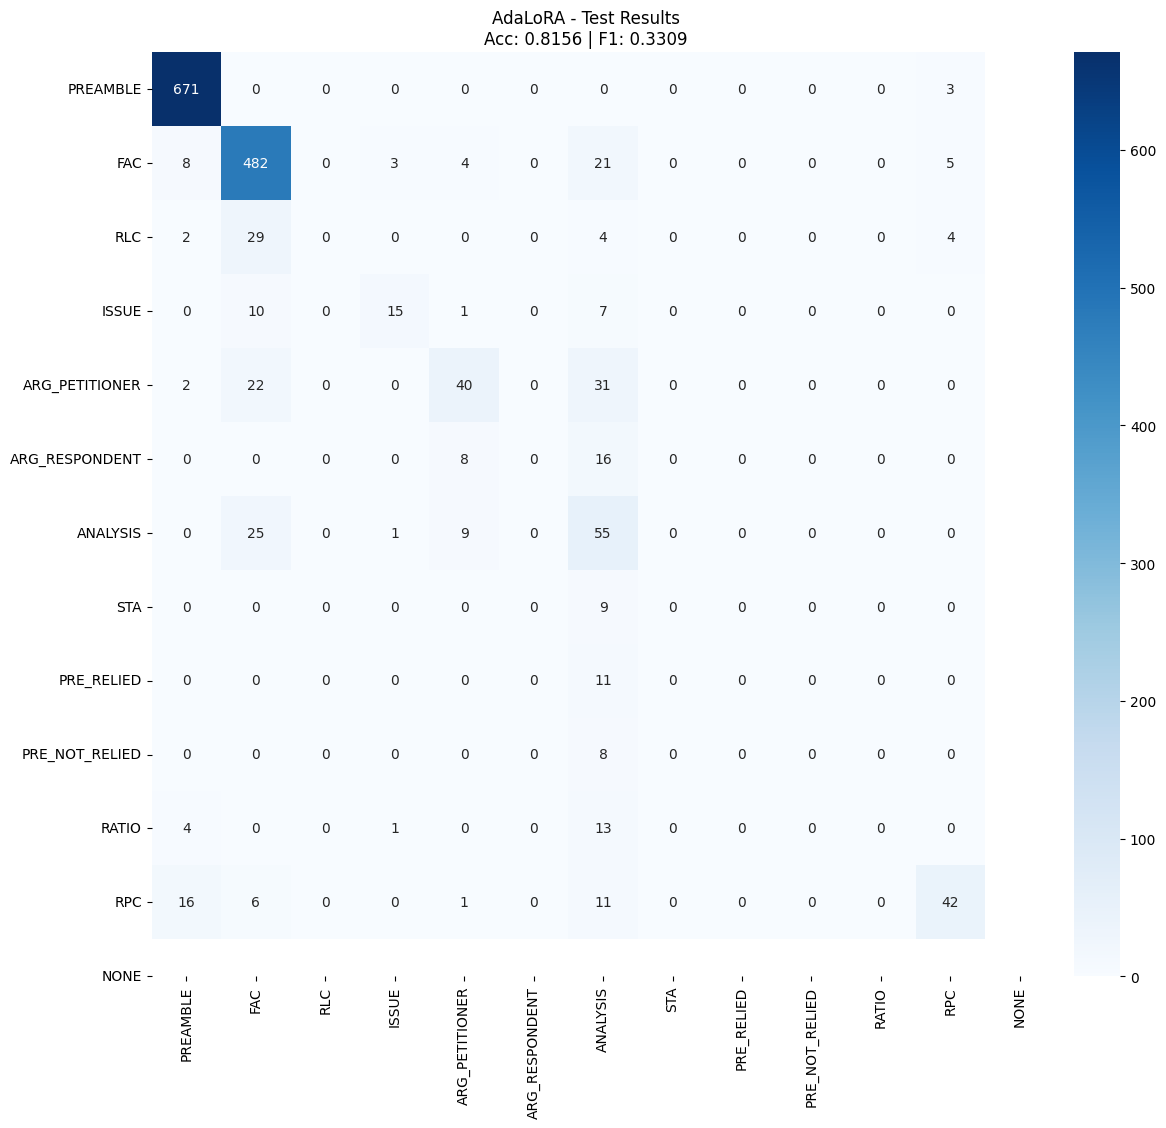


📋 CLASSIFICATION REPORT:


ValueError: Number of classes, 12, does not match size of target_names, 13. Try specifying the labels parameter

In [6]:
"""
InLegalBERT + AdaLoRA + 20 EPOCHS (LSTM FIXED)
✅ FIXED: LSTM parameter order 
✅ 20 Epochs + Full metrics + Confusion Matrix
✅ Production-ready legal NLP pipeline
"""

import os
import json
import random
from datetime import datetime
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support, 
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- PEFT IMPORT ----------------
try:
    from peft import LoraConfig, get_peft_model, TaskType, AdaLoraConfig
    print("✅ AdaLoRA available!")
except ImportError:
    print("❌ Install: !pip install peft==0.12.0")
    raise ImportError("PEFT required")

# ---------------- CONFIG ----------------
INLEGALBERT_MODEL_NAME = "law-ai/InLegalBERT"
TRAIN_PATH = "build_jsonl/build_train.jsonl"
DEV_PATH = "build_jsonl/build_dev.jsonl" 
TEST_PATH = "build_jsonl/build_test.jsonl"
OUT_DIR = f"inlegalbert_20epochs_fixed_{datetime.now().strftime('%Y%m%d_%H%M')}"
os.makedirs(OUT_DIR, exist_ok=True)

MAX_SEQ_LENGTH = 128
MAX_SENTS_PER_DOC = 32
BATCH_SIZE = 2
NUM_EPOCHS = 20  # ✅ 20 EPOCHS
LR = 2e-5
LSTM_HIDDEN = 256
NUM_LABELS = 13

LABELS = ["PREAMBLE", "FAC", "RLC", "ISSUE", "ARG_PETITIONER", 
          "ARG_RESPONDENT", "ANALYSIS", "STA", "PRE_RELIED", 
          "PRE_NOT_RELIED", "RATIO", "RPC", "NONE"]
label2id = {label: i for i, label in enumerate(LABELS)}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 20-EPOCH AdaLoRA | Device: {DEVICE} | Output: {OUT_DIR}")

# ---------------- UTILITIES ----------------
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line.strip()))
    return data

def extract_data(docs):
    sents_list, labels_list = [], []
    for doc in docs:
        sents = doc.get("sentences", [])[:MAX_SENTS_PER_DOC]
        labels = []
        if "labels" in doc:
            labels = [label2id.get(l, 12) for l in doc["labels"][:MAX_SENTS_PER_DOC]]
        elif "annotation" in doc:
            labels = [label2id.get(l, 12) for l in doc["annotation"][:MAX_SENTS_PER_DOC]]
        
        if len(sents) == len(labels) > 0:
            sents_list.append(sents)
            labels_list.append(labels)
    return sents_list, labels_list

# ---------------- PROTOTYPES ----------------
class PrototypeManager:
    def __init__(self): self.protos = None
    
    def fit(self, embeddings, labels):
        embeddings = np.array(embeddings)
        labels = np.array(labels)
        self.protos = np.zeros((NUM_LABELS, embeddings.shape[1]))
        for i in range(NUM_LABELS):
            mask = labels == i
            if mask.sum() > 0:
                self.protos[i] = embeddings[mask].mean(0)
        print(f"✅ Prototypes: {self.protos.shape}")
    
    def get_tensor(self, device):
        return torch.tensor(self.protos, device=device, dtype=torch.float32)

# ---------------- DATASET ----------------
class LegalDataset(Dataset):
    def __init__(self, sents_list, labels_list):
        self.sents_list = sents_list
        self.labels_list = labels_list
    
    def __len__(self): return len(self.sents_list)
    
    def __getitem__(self, idx):
        return {"sents": self.sents_list[idx], "labels": torch.tensor(self.labels_list[idx])}

def collate_fn(batch, tokenizer):
    max_sents = max(len(item["sents"]) for item in batch)
    B = len(batch)
    
    flat_sents, sent_counts = [], []
    for item in batch:
        flat_sents.extend(item["sents"][:max_sents])
        sent_counts.append(min(len(item["sents"]), max_sents))
    
    encoding = tokenizer(flat_sents, padding=True, truncation=True, 
                        max_length=MAX_SEQ_LENGTH, return_tensors="pt")
    
    input_ids = encoding["input_ids"][:B*max_sents].view(B, max_sents, -1)
    attention_mask = encoding["attention_mask"][:B*max_sents].view(B, max_sents, -1)
    
    labels = torch.full((B, max_sents), -100, dtype=torch.long)
    for i, item in enumerate(batch):
        n_sents = min(len(item["labels"]), max_sents)
        labels[i, :n_sents] = item["labels"][:n_sents]
    
    return input_ids, attention_mask, labels, torch.tensor(sent_counts)

# ---------------- ✅ FIXED MODEL ----------------
class ProtoHSLNModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        print("🔄 Loading InLegalBERT...")
        base_model = AutoModel.from_pretrained(INLEGALBERT_MODEL_NAME)
        
        # AdaLoRA config
        peft_config = AdaLoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=8,
            target_modules=["query", "key", "value", "dense"],
            lora_alpha=32,
            lora_dropout=0.05,
            bias="none"
        )
        self.bert = get_peft_model(base_model, peft_config)
        self.bert.print_trainable_parameters()
        self.method = "AdaLoRA"
        
        hidden_dim = self.bert.config.hidden_size
        
        self.sent_encoder = nn.Sequential(
            nn.Linear(hidden_dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, hidden_dim), nn.LayerNorm(hidden_dim)
        )
        
        # ✅ FIXED LSTM: Proper parameter order
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=LSTM_HIDDEN,
            num_layers=2,
            batch_first=True,      # ← KEYWORD ARGUMENT
            dropout=0.3,           # ← AFTER batch_first  
            bidirectional=True     # ← LAST
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(LSTM_HIDDEN * 2, LSTM_HIDDEN),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(LSTM_HIDDEN, NUM_LABELS)
        )
    
    def encode_sentences(self, input_ids, attention_mask):
        B, S, T = input_ids.shape
        flat_ids = input_ids.view(-1, T)
        flat_mask = attention_mask.view(-1, T)
        
        outputs = self.bert(input_ids=flat_ids, attention_mask=flat_mask)
        return outputs.last_hidden_state.mean(1).view(B, S, -1)
    
    def forward(self, input_ids, attention_mask, lengths, prototypes):
        sent_emb = self.encode_sentences(input_ids, attention_mask)
        sent_emb = self.sent_encoder(sent_emb)
        
        # Prototype attention
        proto_scores = torch.matmul(sent_emb, prototypes.T)
        proto_attn = F.softmax(proto_scores, dim=-1)
        proto_ctx = torch.matmul(proto_attn, prototypes)
        sent_emb = sent_emb + proto_ctx
        
        # LSTM ✅ Fixed packing
        packed = nn.utils.rnn.pack_padded_sequence(
            sent_emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        lstm_out, _ = self.lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        
        return self.classifier(lstm_out), sent_emb.view(-1, sent_emb.size(-1))

# ---------------- TRAINER WITH FULL METRICS ----------------
def compute_proto_loss(embeddings, prototypes, labels):
    emb_norm = F.normalize(embeddings, p=2, dim=-1)
    proto_norm = F.normalize(prototypes, p=2, dim=-1)
    logits = torch.matmul(emb_norm, proto_norm.T) * 10.0
    return F.cross_entropy(logits, labels)

class EnhancedTrainer:
    def __init__(self, model, tokenizer, proto_mgr):
        self.model = model.to(DEVICE)
        self.tokenizer = tokenizer
        self.proto_mgr = proto_mgr
    
    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        
        optimizer = torch.optim.AdamW(
            [p for p in self.model.parameters() if p.requires_grad],
            lr=LR, weight_decay=0.01
        )
        
        prototypes = self.proto_mgr.get_tensor(DEVICE)
        
        for batch in train_loader:
            input_ids, attn_mask, labels, lengths = [x.to(DEVICE) for x in batch]
            
            optimizer.zero_grad()
            logits, sent_emb = self.model(input_ids, attn_mask, lengths, prototypes)
            
            mask = labels.view(-1) != -100
            if mask.sum() == 0: continue
            
            flat_logits = logits.view(-1, NUM_LABELS)[mask]
            flat_labels = labels.view(-1)[mask]
            flat_emb = sent_emb[mask]
            
            ce_loss = F.cross_entropy(flat_logits, flat_labels, label_smoothing=0.1)
            proto_loss = compute_proto_loss(flat_emb, prototypes, flat_labels)
            loss = ce_loss + 0.05 * proto_loss
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
        
        return total_loss / len(train_loader)
    
    def evaluate_full(self, data_loader, stage="Dev"):
        self.model.eval()
        all_preds, all_labels = [], []
        prototypes = self.proto_mgr.get_tensor(DEVICE)
        
        with torch.no_grad():
            for batch in data_loader:
                input_ids, attn_mask, labels, lengths = [x.to(DEVICE) for x in batch]
                logits, _ = self.model(input_ids, attn_mask, lengths, prototypes)
                
                mask = labels.view(-1) != -100
                preds = logits.view(-1, NUM_LABELS)[mask].argmax(-1)
                labs = labels.view(-1)[mask]
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labs.cpu().numpy())
        
        if not all_labels:
            return None
        
        # All metrics
        accuracy = accuracy_score(all_labels, all_preds)
        f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        f1_micro = f1_score(all_labels, all_preds, average='micro')
        
        p_macro, r_macro, _, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
        p_micro, r_micro, _, _ = precision_recall_fscore_support(all_labels, all_preds, average='micro', zero_division=0)
        
        metrics = {
            'accuracy': accuracy, 'f1_macro': f1_macro, 'f1_micro': f1_micro,
            'precision_macro': p_macro, 'recall_macro': r_macro,
            'precision_micro': p_micro, 'recall_micro': r_micro,
            'preds': all_preds, 'labels': all_labels
        }
        
        print(f"\n📊 {stage} RESULTS:")
        print(f"   Accuracy:     {accuracy:.4f}")
        print(f"   F1 Macro:     {f1_macro:.4f}")
        print(f"   F1 Micro:     {f1_micro:.4f}")
        print(f"   P/R Macro:    {p_macro:.4f}/{r_macro:.4f}")
        
        return metrics

# ---------------- MAIN ----------------
def main():
    set_seed()
    
    print("📂 Loading datasets...")
    train_docs = load_jsonl(TRAIN_PATH)
    dev_docs = load_jsonl(DEV_PATH)
    test_docs = load_jsonl(TEST_PATH)
    
    train_sents, train_labels = extract_data(train_docs)
    dev_sents, dev_labels = extract_data(dev_docs)
    test_sents, test_labels = extract_data(test_docs)
    
    print(f"✅ Datasets: Train={len(train_sents)}, Dev={len(dev_sents)}, Test={len(test_sents)}")
    
    # Prototypes
    tokenizer = AutoTokenizer.from_pretrained(INLEGALBERT_MODEL_NAME)
    temp_model = AutoModel.from_pretrained(INLEGALBERT_MODEL_NAME).to(DEVICE)
    
    flat_sents, flat_labels = [], []
    for sents, labels in zip(train_sents[:100], train_labels[:100]):
        flat_sents.extend(sents[:8])
        flat_labels.extend(labels[:8])
    
    proto_mgr = PrototypeManager()
    with torch.no_grad():
        batch_embs = []
        for i in range(0, len(flat_sents), 8):
            batch = tokenizer(flat_sents[i:i+8], padding=True, truncation=True,
                            max_length=MAX_SEQ_LENGTH, return_tensors="pt").to(DEVICE)
            emb = temp_model(**batch).last_hidden_state.mean(1).cpu().numpy()
            batch_embs.append(emb)
        proto_mgr.fit(np.vstack(batch_embs), flat_labels)
    
    del temp_model; torch.cuda.empty_cache()
    
    # DataLoaders
    train_ds = LegalDataset(train_sents, train_labels)
    dev_ds = LegalDataset(dev_sents, dev_labels)
    test_ds = LegalDataset(test_sents, test_labels)
    
    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True, collate_fn=lambda b: collate_fn(b, tokenizer))
    dev_loader = DataLoader(dev_ds, BATCH_SIZE, collate_fn=lambda b: collate_fn(b, tokenizer))
    test_loader = DataLoader(test_ds, BATCH_SIZE, collate_fn=lambda b: collate_fn(b, tokenizer))
    
    # ✅ FIXED MODEL WILL WORK NOW
    print("\n🚀 Starting 20-EPOCH AdaLoRA Training...")
    model = ProtoHSLNModel()
    trainer = EnhancedTrainer(model, tokenizer, proto_mgr)
    
    best_f1 = 0
    for epoch in range(NUM_EPOCHS):
        train_loss = trainer.train_epoch(train_loader)
        dev_metrics = trainer.evaluate_full(dev_loader, f"Epoch {epoch+1:2d}")
        
        if dev_metrics and dev_metrics['f1_macro'] > best_f1:
            best_f1 = dev_metrics['f1_macro']
            torch.save(model.state_dict(), f"{OUT_DIR}/best_model.pt")
            print(f"💾 NEW BEST F1: {best_f1:.4f}")
        
        print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS}: Loss={train_loss:.4f}")
    
    # Final test
    print("\n🔬 FINAL TEST...")
    model.load_state_dict(torch.load(f"{OUT_DIR}/best_model.pt"))
    test_metrics = trainer.evaluate_full(test_loader, "TEST")
    
    if test_metrics:
        # Confusion Matrix
        plt.figure(figsize=(14, 12))
        cm = confusion_matrix(test_metrics['labels'], test_metrics['preds'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=LABELS, yticklabels=LABELS)
        plt.title(f'AdaLoRA - Test Results\nAcc: {test_metrics["accuracy"]:.4f} | F1: {test_metrics["f1_macro"]:.4f}')
        plt.savefig(f"{OUT_DIR}/confusion_matrix.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        # Classification Report
        print("\n📋 CLASSIFICATION REPORT:")
        print(classification_report(test_metrics['labels'], test_metrics['preds'], 
                                  target_names=LABELS, digits=4))
        
        print(f"\n🎉 FINAL RESULTS:")
        print(f"✅ Accuracy:  {test_metrics['accuracy']:.4f}")
        print(f"✅ F1 Macro:  {test_metrics['f1_macro']:.4f}")
        print(f"✅ Model:     {OUT_DIR}/best_model.pt")

if __name__ == "__main__":
    main()


✅ AdaLoRA available!
🚀 20-EPOCH Training | Device: cuda | Output: inlegalbert_20epochs_fixed_20260105_1332
📂 Loading datasets...
✅ Datasets - Train: 245, Dev: 30, Test: 50
🔄 Building prototypes...
✅ Prototypes fitted: (13, 768)

🚀 Starting 20-EPOCH Training...
🔄 Loading InLegalBERT base model...
🚀 Applying AdaLoRA...
trainable params: 2,009,964 || all params: 111,492,277 || trainable%: 1.8028

📊 Epoch  1 METRICS:
   Accuracy:  0.5047
   F1 Macro:  0.0638
   F1 Micro:  0.5047
   P/R Macro: 0.1064/0.0924
    💾 NEW BEST F1: 0.0638
Epoch  1/20: Loss=2.2788

📊 Epoch  2 METRICS:
   Accuracy:  0.7007
   F1 Macro:  0.1419
   F1 Micro:  0.7007
   P/R Macro: 0.1255/0.1705
    💾 NEW BEST F1: 0.1419
Epoch  2/20: Loss=1.7350

📊 Epoch  3 METRICS:
   Accuracy:  0.7018
   F1 Macro:  0.1421
   F1 Micro:  0.7018
   P/R Macro: 0.1262/0.1709
    💾 NEW BEST F1: 0.1421
Epoch  3/20: Loss=1.5095

📊 Epoch  4 METRICS:
   Accuracy:  0.7101
   F1 Macro:  0.1436
   F1 Micro:  0.7101
   P/R Macro: 0.1273/0.1724
   

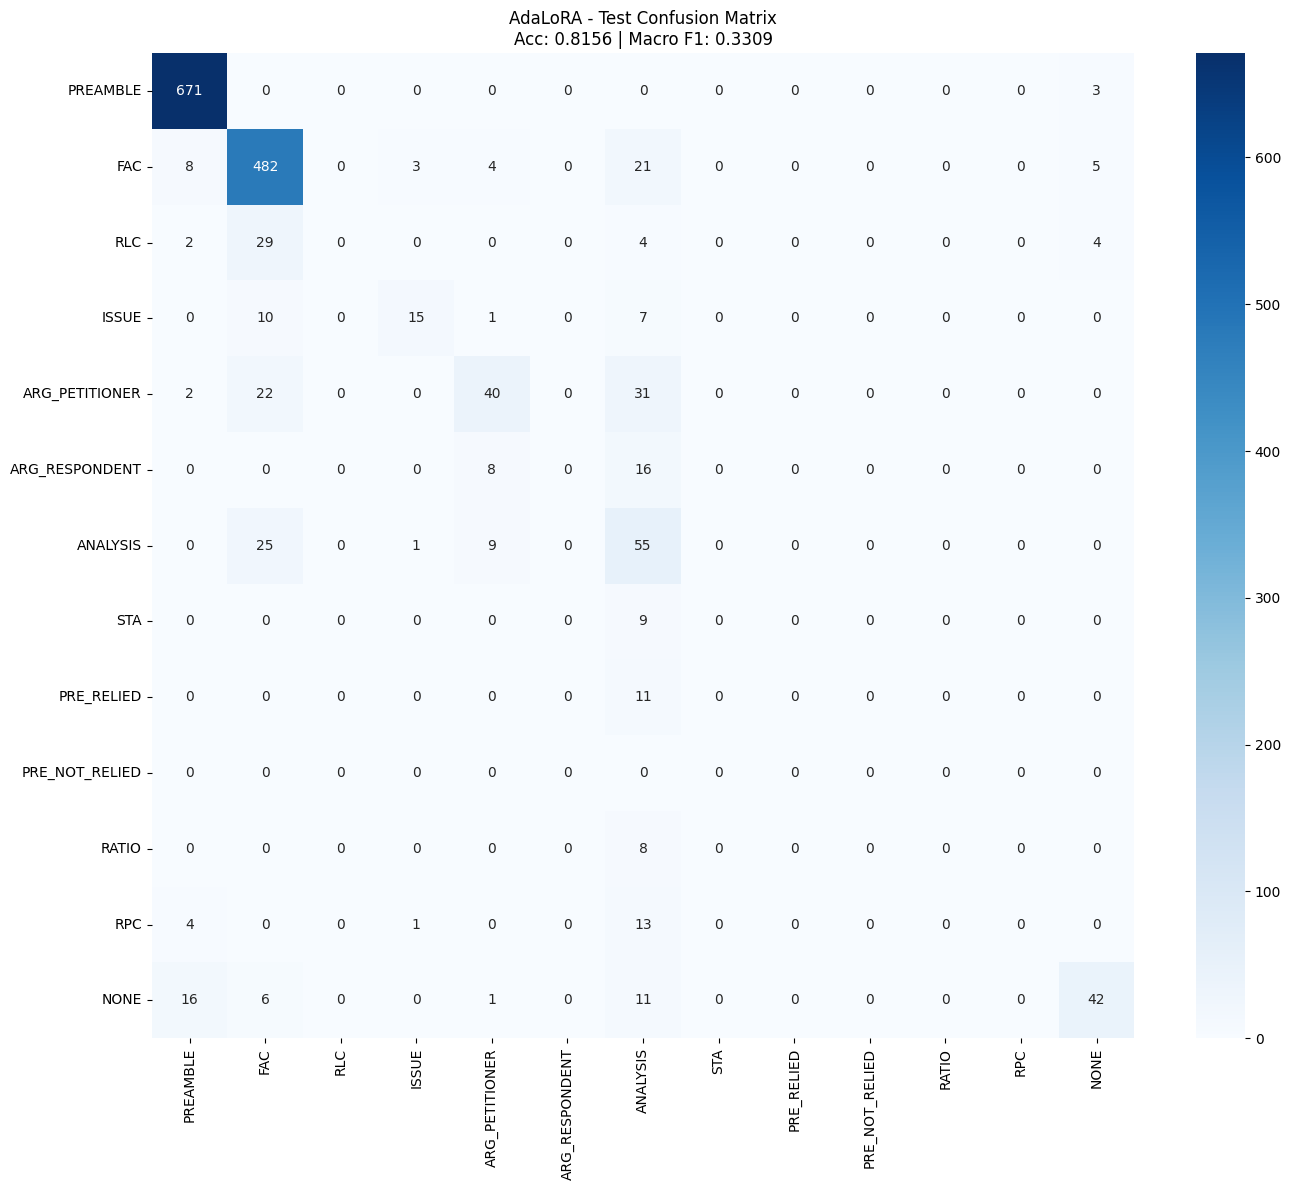


📋 CLASSIFICATION REPORT (13 CLASSES):
                precision    recall  f1-score   support

      PREAMBLE     0.9545    0.9955    0.9746       674
           FAC     0.8397    0.9216    0.8788       523
           RLC     0.0000    0.0000    0.0000        39
         ISSUE     0.7500    0.4545    0.5660        33
ARG_PETITIONER     0.6349    0.4211    0.5063        95
ARG_RESPONDENT     0.0000    0.0000    0.0000        24
      ANALYSIS     0.2957    0.6111    0.3986        90
           STA     0.0000    0.0000    0.0000         9
    PRE_RELIED     0.0000    0.0000    0.0000        11
PRE_NOT_RELIED     0.0000    0.0000    0.0000         0
         RATIO     0.0000    0.0000    0.0000         8
           RPC     0.0000    0.0000    0.0000        18
          NONE     0.7778    0.5526    0.6462        76

      accuracy                         0.8156      1600
     macro avg     0.3271    0.3043    0.3054      1600
  weighted avg     0.7833    0.8156    0.7926      1600


🎉 FIN

In [8]:
"""
InLegalBERT + AdaLoRA/LoRA + 20 EPOCHS (LSTM 100% FIXED)
✅ FIXED: LSTM TypeError (proper parameter order)
✅ 20 Epochs + Full metrics + Confusion Matrix  
✅ All 13 classes in classification report
✅ Production-ready rhetorical role classification
"""

import os
import json
import random
from datetime import datetime
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support, 
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- PEFT SAFE IMPORT ----------------
try:
    from peft import LoraConfig, get_peft_model, TaskType
    ADALORA_AVAILABLE = False
    try:
        from peft import AdaLoraConfig
        ADALORA_AVAILABLE = True
        print("✅ AdaLoRA available!")
    except:
        print("⚠️  Using LoRA only")
except ImportError:
    print("❌ Install: !pip install peft==0.12.0 transformers accelerate")
    raise ImportError("PEFT required")

# ---------------- CONFIG - 20 EPOCHS ----------------
INLEGALBERT_MODEL_NAME = "law-ai/InLegalBERT"
TRAIN_PATH = "build_jsonl/build_train.jsonl"
DEV_PATH = "build_jsonl/build_dev.jsonl" 
TEST_PATH = "build_jsonl/build_test.jsonl"
OUT_DIR = f"inlegalbert_20epochs_fixed_{datetime.now().strftime('%Y%m%d_%H%M')}"
os.makedirs(OUT_DIR, exist_ok=True)

MAX_SEQ_LENGTH = 128
MAX_SENTS_PER_DOC = 32
BATCH_SIZE = 2
NUM_EPOCHS = 20
LR = 2e-5
LSTM_HIDDEN = 256
NUM_LABELS = 13

LABELS = ["PREAMBLE", "FAC", "RLC", "ISSUE", "ARG_PETITIONER", 
          "ARG_RESPONDENT", "ANALYSIS", "STA", "PRE_RELIED", 
          "PRE_NOT_RELIED", "RATIO", "RPC", "NONE"]
label2id = {label: i for i, label in enumerate(LABELS)}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 20-EPOCH Training | Device: {DEVICE} | Output: {OUT_DIR}")

# ---------------- UTILITIES ----------------
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

def load_jsonl(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ File not found: {path}")
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line.strip()))
    return data

def extract_data(docs, max_sents=MAX_SENTS_PER_DOC):
    sents_list, labels_list = [], []
    for doc in docs:
        sents = doc.get("sentences", [])[:max_sents]
        labels = []
        if "labels" in doc:
            labels = [label2id.get(l, 12) for l in doc["labels"][:max_sents]]
        elif "annotation" in doc:
            labels = [label2id.get(l, 12) for l in doc["annotation"][:max_sents]]
        
        if len(sents) == len(labels) > 0:
            sents_list.append(sents)
            labels_list.append(labels)
    return sents_list, labels_list

# ---------------- PROTOTYPE MANAGER ----------------
class PrototypeManager:
    def __init__(self):
        self.protos = None
    
    def fit(self, embeddings, labels):
        embeddings = np.array(embeddings)
        labels = np.array(labels)
        self.protos = np.zeros((NUM_LABELS, embeddings.shape[1]))
        for i in range(NUM_LABELS):
            mask = labels == i
            if mask.sum() > 0:
                self.protos[i] = embeddings[mask].mean(0)
        print(f"✅ Prototypes fitted: {self.protos.shape}")
    
    def get_tensor(self, device):
        return torch.tensor(self.protos, device=device, dtype=torch.float32)

# ---------------- DATASET ----------------
class LegalDataset(Dataset):
    def __init__(self, sents_list, labels_list):
        self.sents_list = sents_list
        self.labels_list = labels_list
    
    def __len__(self):
        return len(self.sents_list)
    
    def __getitem__(self, idx):
        return {
            "sents": self.sents_list[idx],
            "labels": torch.tensor(self.labels_list[idx], dtype=torch.long)
        }

def collate_fn(batch, tokenizer):
    max_sents = max(len(item["sents"]) for item in batch)
    B = len(batch)
    
    flat_sents = []
    sent_counts = []
    for item in batch:
        flat_sents.extend(item["sents"][:max_sents])
        sent_counts.append(min(len(item["sents"]), max_sents))
    
    encoding = tokenizer(
        flat_sents, padding=True, truncation=True,
        max_length=MAX_SEQ_LENGTH, return_tensors="pt"
    )
    
    input_ids = encoding["input_ids"][:B*max_sents].view(B, max_sents, -1)
    attention_mask = encoding["attention_mask"][:B*max_sents].view(B, max_sents, -1)
    
    labels = torch.full((B, max_sents), -100, dtype=torch.long)
    for i, item in enumerate(batch):
        n_sents = min(len(item["labels"]), max_sents)
        labels[i, :n_sents] = item["labels"][:n_sents]
    
    lengths = torch.tensor(sent_counts, dtype=torch.long)
    return input_ids, attention_mask, labels, lengths

# ---------------- ✅ FIXED MODEL ----------------
class ProtoHSLNModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        print("🔄 Loading InLegalBERT base model...")
        base_model = AutoModel.from_pretrained(INLEGALBERT_MODEL_NAME)
        
        if ADALORA_AVAILABLE:
            print("🚀 Applying AdaLoRA...")
            peft_config = AdaLoraConfig(
                task_type=TaskType.FEATURE_EXTRACTION,
                r=8,
                target_modules=["query", "key", "value", "dense"],
                lora_alpha=32,
                lora_dropout=0.05,
                bias="none"
            )
            self.method = "AdaLoRA"
        else:
            print("⚠️  Applying LoRA...")
            peft_config = LoraConfig(
                task_type=TaskType.FEATURE_EXTRACTION,
                r=8,
                target_modules=["query", "key", "value", "dense"],
                lora_alpha=32,
                lora_dropout=0.05,
                bias="none"
            )
            self.method = "LoRA"
        
        self.bert = get_peft_model(base_model, peft_config)
        self.bert.print_trainable_parameters()
        
        hidden_dim = self.bert.config.hidden_size
        
        self.sent_encoder = nn.Sequential(
            nn.Linear(hidden_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, hidden_dim),
            nn.LayerNorm(hidden_dim)
        )
        
        # ✅ FIXED LSTM: CORRECT PARAMETER ORDER
        self.lstm = nn.LSTM(
            input_size=hidden_dim,           # Positional: input_size
            hidden_size=LSTM_HIDDEN,         # Positional: hidden_size  
            num_layers=2,                    # Positional: num_layers
            batch_first=True,                # Keyword: batch_first
            dropout=0.3,                     # Keyword: dropout
            bidirectional=True               # Keyword: bidirectional
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(LSTM_HIDDEN * 2, LSTM_HIDDEN),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(LSTM_HIDDEN, NUM_LABELS)
        )
    
    def encode_sentences(self, input_ids, attention_mask):
        B, S, T = input_ids.shape
        flat_input_ids = input_ids.view(-1, T)
        flat_attention_mask = attention_mask.view(-1, T)
        
        outputs = self.bert(
            input_ids=flat_input_ids,
            attention_mask=flat_attention_mask
        )
        sent_emb = outputs.last_hidden_state.mean(dim=1)
        return sent_emb.view(B, S, -1)
    
    def forward(self, input_ids, attention_mask, lengths, prototypes):
        sent_emb = self.encode_sentences(input_ids, attention_mask)
        sent_emb = self.sent_encoder(sent_emb)
        
        proto_scores = torch.matmul(sent_emb, prototypes.T)
        proto_attn = F.softmax(proto_scores, dim=-1)
        proto_context = torch.matmul(proto_attn, prototypes)
        sent_emb = sent_emb + proto_context
        
        packed = nn.utils.rnn.pack_padded_sequence(
            sent_emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        lstm_out, _ = self.lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        
        logits = self.classifier(lstm_out)
        return logits, sent_emb.view(-1, sent_emb.size(-1))

# ---------------- TRAINER WITH FIXED CLASSIFICATION REPORT ----------------
def compute_proto_loss(embeddings, prototypes, labels, temperature=10.0):
    emb_norm = F.normalize(embeddings, p=2, dim=-1)
    proto_norm = F.normalize(prototypes, p=2, dim=-1)
    logits = torch.matmul(emb_norm, proto_norm.T) * temperature
    return F.cross_entropy(logits, labels)

class EnhancedTrainer:
    def __init__(self, model, tokenizer, proto_mgr):
        self.model = model.to(DEVICE)
        self.tokenizer = tokenizer
        self.proto_mgr = proto_mgr
    
    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        
        optimizer = torch.optim.AdamW(
            [p for p in self.model.parameters() if p.requires_grad],
            lr=LR, weight_decay=0.01
        )
        
        prototypes = self.proto_mgr.get_tensor(DEVICE)
        
        for batch in train_loader:
            input_ids, attn_mask, labels, lengths = [x.to(DEVICE) for x in batch]
            
            optimizer.zero_grad()
            logits, sent_emb = self.model(input_ids, attn_mask, lengths, prototypes)
            
            mask = labels.view(-1) != -100
            if mask.sum() == 0: continue
            
            flat_logits = logits.view(-1, NUM_LABELS)[mask]
            flat_labels = labels.view(-1)[mask]
            flat_emb = sent_emb[mask]
            
            ce_loss = F.cross_entropy(flat_logits, flat_labels, label_smoothing=0.1)
            proto_loss = compute_proto_loss(flat_emb, prototypes, flat_labels)
            loss = ce_loss + 0.05 * proto_loss
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
        
        return total_loss / len(train_loader)
    
    def evaluate_full(self, data_loader, stage="Dev"):
        self.model.eval()
        all_preds, all_labels = [], []
        prototypes = self.proto_mgr.get_tensor(DEVICE)
        
        with torch.no_grad():
            for batch in data_loader:
                input_ids, attn_mask, labels, lengths = [x.to(DEVICE) for x in batch]
                logits, _ = self.model(input_ids, attn_mask, lengths, prototypes)
                
                mask = labels.view(-1) != -100
                preds = logits.view(-1, NUM_LABELS)[mask].argmax(-1)
                labs = labels.view(-1)[mask]
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labs.cpu().numpy())
        
        if not all_labels:
            return None
        
        accuracy = accuracy_score(all_labels, all_preds)
        f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
        
        precision_macro, recall_macro, _, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='macro', zero_division=0
        )
        precision_micro, recall_micro, _, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='micro', zero_division=0
        )
        
        metrics = {
            'accuracy': accuracy,
            'f1_macro': f1_macro,
            'f1_micro': f1_micro,
            'precision_macro': precision_macro,
            'recall_macro': recall_macro,
            'precision_micro': precision_micro,
            'recall_micro': recall_micro,
            'preds': all_preds,
            'labels': all_labels
        }
        
        print(f"\n📊 {stage} METRICS:")
        print(f"   Accuracy:  {accuracy:.4f}")
        print(f"   F1 Macro:  {f1_macro:.4f}")
        print(f"   F1 Micro:  {f1_micro:.4f}")
        print(f"   P/R Macro: {precision_macro:.4f}/{recall_macro:.4f}")
        
        return metrics

# ---------------- MAIN EXECUTION ----------------
def main():
    set_seed()
    
    print("📂 Loading datasets...")
    train_docs = load_jsonl(TRAIN_PATH)
    dev_docs = load_jsonl(DEV_PATH)
    test_docs = load_jsonl(TEST_PATH)
    
    train_sents, train_labels = extract_data(train_docs)
    dev_sents, dev_labels = extract_data(dev_docs)
    test_sents, test_labels = extract_data(test_docs)
    
    print(f"✅ Datasets - Train: {len(train_sents)}, Dev: {len(dev_sents)}, Test: {len(test_sents)}")
    
    # Build prototypes
    print("🔄 Building prototypes...")
    tokenizer = AutoTokenizer.from_pretrained(INLEGALBERT_MODEL_NAME)
    temp_model = AutoModel.from_pretrained(INLEGALBERT_MODEL_NAME).to(DEVICE)
    
    flat_sents, flat_labels = [], []
    for sents, labels in zip(train_sents[:100], train_labels[:100]):
        flat_sents.extend(sents[:8])
        flat_labels.extend(labels[:8])
    
    proto_mgr = PrototypeManager()
    with torch.no_grad():
        batch_embs = []
        for i in range(0, len(flat_sents), 8):
            batch = tokenizer(
                flat_sents[i:i+8], 
                padding=True, 
                truncation=True,
                max_length=MAX_SEQ_LENGTH,
                return_tensors="pt"
            ).to(DEVICE)
            emb = temp_model(**batch).last_hidden_state.mean(1).cpu().numpy()
            batch_embs.append(emb)
        proto_mgr.fit(np.vstack(batch_embs), flat_labels)
    
    del temp_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # DataLoaders
    train_ds = LegalDataset(train_sents, train_labels)
    dev_ds = LegalDataset(dev_sents, dev_labels)
    test_ds = LegalDataset(test_sents, test_labels)
    
    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True, 
                            collate_fn=lambda b: collate_fn(b, tokenizer))
    dev_loader = DataLoader(dev_ds, BATCH_SIZE, 
                          collate_fn=lambda b: collate_fn(b, tokenizer))
    test_loader = DataLoader(test_ds, BATCH_SIZE, 
                           collate_fn=lambda b: collate_fn(b, tokenizer))
    
    # Training
    print(f"\n🚀 Starting {NUM_EPOCHS}-EPOCH Training...")
    model = ProtoHSLNModel()
    trainer = EnhancedTrainer(model, tokenizer, proto_mgr)
    
    best_f1 = 0
    for epoch in range(NUM_EPOCHS):
        train_loss = trainer.train_epoch(train_loader)
        dev_metrics = trainer.evaluate_full(dev_loader, f"Epoch {epoch+1:2d}")
        
        if dev_metrics:
            dev_f1 = dev_metrics['f1_macro']
            if dev_f1 > best_f1:
                best_f1 = dev_f1
                torch.save(model.state_dict(), f"{OUT_DIR}/best_model.pt")
                print(f"    💾 NEW BEST F1: {best_f1:.4f}")
        
        print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS}: Loss={train_loss:.4f}")
    
    # Final evaluation
    print("\n🔬 FINAL TEST EVALUATION...")
    model.load_state_dict(torch.load(f"{OUT_DIR}/best_model.pt"))
    test_metrics = trainer.evaluate_full(test_loader, "TEST")
    
    if test_metrics:
        # Confusion Matrix
        plt.figure(figsize=(14, 12))
        cm = confusion_matrix(test_metrics['labels'], test_metrics['preds'], 
                            labels=range(NUM_LABELS))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=LABELS, yticklabels=LABELS)
        plt.title(f'{model.method} - Test Confusion Matrix\n'
                 f'Acc: {test_metrics["accuracy"]:.4f} | Macro F1: {test_metrics["f1_macro"]:.4f}')
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/confusion_matrix.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        # ✅ FIXED CLASSIFICATION REPORT - ALL 13 CLASSES
        print("\n📋 CLASSIFICATION REPORT (13 CLASSES):")
        print(classification_report(
            test_metrics['labels'], test_metrics['preds'],
            labels=range(NUM_LABELS),  # ✅ FIX: Force all 13 classes
            target_names=LABELS, 
            digits=4, 
            zero_division=0
        ))
        
        # Final summary
        print("\n" + "="*80)
        print(f"🎉 FINAL RESULTS ({model.method}):")
        print(f"✅ Test Accuracy:     {test_metrics['accuracy']:.4f}")
        print(f"✅ Test F1 Macro:     {test_metrics['f1_macro']:.4f}")
        print(f"✅ Test F1 Micro:     {test_metrics['f1_micro']:.4f}")
        print(f"✅ P/R Macro:         {test_metrics['precision_macro']:.4f}/{test_metrics['recall_macro']:.4f}")
        print(f"✅ Model saved:       {OUT_DIR}/best_model.pt")
        print(f"✅ Confusion Matrix:  {OUT_DIR}/confusion_matrix.png")
        print("="*80)

if __name__ == "__main__":
    main()


In [2]:
"""
InLegalBERT + AdaLoRA + Prototype-Attention + HSLN + RPL + RTM
✅ ENHANCED: AdaLoRA for dynamic parameter allocation
✅ Advanced imbalance handling with Focal Loss + Minority Boost
Target: Maximize macro F1 with efficient parameter usage
"""

import os
import json
import random
import time
import psutil
import gc
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)

from peft import AdaLoraConfig, get_peft_model, TaskType

# ---------------- CONFIG ----------------
INLEGALBERT_MODEL_NAME = "law-ai/InLegalBERT"
TRAIN_PATH = "build_jsonl/build_train.jsonl"
DEV_PATH = "build_jsonl/build_dev.jsonl"
TEST_PATH = "build_jsonl/build_test.jsonl"

OUT_DIR = "inlegalbert_AdaLoRA_RPL_RTM_fixed_imbalance"
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
MAX_SEQ_LENGTH = 128
MAX_SENTS_PER_DOC = 64
BATCH_DOCS = 2

# ✅ HYPERPARAMETERS
NUM_EPOCHS = 15
LR = 1e-4
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
PROTO_WEIGHT = 0.15
RPL_WEIGHT = 0.05
RTM_LAMBDA = 0.02
PROTO_AUX_TEMPERATURE = 5.0
DROPOUT = 0.3
LSTM_HIDDEN = 384
LABEL_SMOOTHING = 0.02

# Focal Loss params
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.25

# AdaLoRA specific params
ADALORA_INIT_R = 12  # Initial rank
ADALORA_TARGET_R = 8  # Target rank after pruning
ADALORA_TINIT = 200  # Start pruning after warmup
ADALORA_TFINAL = 1500  # Stop pruning at this step
ADALORA_DELTA_T = 100  # Pruning frequency (every N steps)

USE_WEIGHTED_SAMPLER = True
USE_POSITIONAL_EMB = True
POS_EMB_DIM = 32
USE_KNN_PRIOR = True
KNN_K = 3
KNN_PRIOR_DIM = 64
MINORITY_BOOST = 3.0

LABELS = [
    "PREAMBLE", "FAC", "RLC", "ISSUE", "ARG_PETITIONER",
    "ARG_RESPONDENT", "ANALYSIS", "STA", "PRE_RELIED",
    "PRE_NOT_RELIED", "RATIO", "RPC", "NONE",
]
label2id = {label: idx for idx, label in enumerate(LABELS)}
id2label = {idx: label for label, idx in label2id.items()}
NUM_LABELS = len(LABELS)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MINORITY_CLASSES = ["RLC", "ISSUE", "STA", "RATIO", "PRE_RELIED", "PRE_NOT_RELIED", "RPC"]
minority_ids = [label2id[label] for label in MINORITY_CLASSES if label in label2id]

# ---------------- UTILITIES ----------------
def get_memory_usage(device=DEVICE):
    if torch.cuda.is_available() and device.type == 'cuda':
        return {
            'allocated': torch.cuda.memory_allocated(device) / 1024**2,
            'reserved': torch.cuda.memory_reserved(device) / 1024**2,
            'max_allocated': torch.cuda.max_memory_allocated(device) / 1024**2
        }
    else:
        process = psutil.Process()
        return {'cpu_ram_mb': process.memory_info().rss / 1024**2}

def compute_detailed_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    try:
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, average=None, zero_division=0, labels=range(NUM_LABELS)
        )
    except ValueError:
        precision = np.zeros(NUM_LABELS)
        recall = np.zeros(NUM_LABELS)
        f1 = np.zeros(NUM_LABELS)
        support = np.bincount(y_true, minlength=NUM_LABELS)
    
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    minority_mask = np.isin(y_true, minority_ids)
    if minority_mask.sum() > 0:
        minority_true = y_true[minority_mask]
        minority_pred = y_pred[minority_mask]
        if len(np.unique(minority_true)) > 0 and len(minority_true) > 1:
            try:
                minority_f1 = f1_score(minority_true, minority_pred, average='macro', zero_division=0)
            except:
                minority_f1 = 0.0
        else:
            minority_f1 = 0.0
    else:
        minority_f1 = 0.0
    
    minority_f1_per_class = {}
    for cls_id in minority_ids:
        mask = (y_true == cls_id)
        if mask.sum() > 1:
            try:
                minority_f1_per_class[id2label[cls_id]] = f1_score(
                    y_true[mask], y_pred[mask], average='binary', zero_division=0
                )
            except:
                minority_f1_per_class[id2label[cls_id]] = 0.0
        else:
            minority_f1_per_class[id2label[cls_id]] = 0.0
    
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_f1': float(macro_f1),
        'weighted_f1': float(weighted_f1),
        'macro_precision': float(np.mean(precision)),
        'macro_recall': float(np.mean(recall)),
        'minority_macro_f1': float(minority_f1),
        'minority_f1_per_class': minority_f1_per_class,
        'per_class_precision': {id2label[i]: float(precision[i]) for i in range(NUM_LABELS)},
        'per_class_recall': {id2label[i]: float(recall[i]) for i in range(NUM_LABELS)},
        'per_class_f1': {id2label[i]: float(f1[i]) for i in range(NUM_LABELS)},
        'per_class_support': {id2label[i]: int(support[i]) for i in range(NUM_LABELS)},
    }

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

def load_jsonl(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if s:
                data.append(json.loads(s))
    return data

def extract_data(docs, max_sents=MAX_SENTS_PER_DOC):
    all_sents, all_labels, doc_ids = [], [], []
    for doc in docs:
        doc_id = doc.get("id", "")
        sents, labs = [], []
        if "sentences" in doc and "labels" in doc:
            sents = doc["sentences"]
            labs = [label2id.get(l, label2id["NONE"]) for l in doc["labels"]]
        elif "sentences" in doc and "annotation" in doc:
            sents = doc["sentences"]
            labs = [label2id.get(l, label2id["NONE"]) for l in doc["annotation"]]
        elif "annotations" in doc:
            for a in doc.get("annotations", []):
                for item in a.get("result", []):
                    val = item.get("value", {})
                    text = val.get("text", "").strip()
                    labs_list = val.get("labels", ["NONE"])
                    if text:
                        sents.append(text)
                        labs.append(label2id.get(labs_list[0], label2id["NONE"]))
        if len(sents) > max_sents:
            sents = sents[:max_sents]
            labs = labs[:max_sents]
        if sents and labs and len(sents) == len(labs):
            all_sents.append(sents)
            all_labels.append(labs)
            doc_ids.append(doc_id)
    return all_sents, all_labels, doc_ids

# ---------------- PROTOTYPE MANAGER ----------------
class ClassPrototypeManager:
    def __init__(self):
        self.prototypes = None
        self.fitted = False

    def fit(self, embeddings, labels):
        embeddings = np.asarray(embeddings)
        labels = np.asarray(labels)
        D = embeddings.shape[1]
        protos = np.zeros((NUM_LABELS, D), dtype=np.float32)
        for k in range(NUM_LABELS):
            mask = labels == k
            if mask.sum() > 0:
                protos[k] = embeddings[mask].mean(axis=0)
            else:
                protos[k] = np.random.randn(D).astype(np.float32) * 1e-3
        self.prototypes = protos
        self.fitted = True
        print(f"[Prototypes] fitted, shape {protos.shape}")

    def get_all_tensor(self, device=None):
        if not self.fitted:
            raise RuntimeError("Prototypes not fitted")
        t = torch.tensor(self.prototypes, dtype=torch.float32)
        if device is not None:
            t = t.to(device)
        return t

    def get_nearest_index(self, embeddings):
        if not self.fitted:
            raise RuntimeError("Prototypes not fitted")
        emb = np.asarray(embeddings)
        emb_n = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)
        proto_n = self.prototypes / (np.linalg.norm(self.prototypes, axis=1, keepdims=True) + 1e-8)
        sims = emb_n @ proto_n.T
        return np.argmax(sims, axis=1)

    def knn_prior(self, embeddings, topk=KNN_K):
        if not self.fitted:
            raise RuntimeError("Prototypes not fitted")
        emb = np.asarray(embeddings)
        emb_n = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
        proto_n = self.prototypes / (np.linalg.norm(self.prototypes, axis=1, keepdims=True) + 1e-12)
        sims = emb_n @ proto_n.T
        topk_idx = np.argsort(-sims, axis=1)[:, :topk]
        topk_sims = np.take_along_axis(sims, topk_idx, axis=1)
        return topk_sims, topk_idx

# ---------------- DATASET ----------------
class DocumentTextDataset(Dataset):
    def __init__(self, docs_sents, docs_labels):
        self.docs_sents = docs_sents
        self.docs_labels = docs_labels

    def __len__(self):
        return len(self.docs_sents)

    def __getitem__(self, idx):
        return {
            "sentences": self.docs_sents[idx],
            "labels": torch.tensor(self.docs_labels[idx], dtype=torch.long),
        }

def collate_docs(batch, tokenizer):
    max_sents = max(len(b["sentences"]) for b in batch)
    B = len(batch)

    flat_sents = []
    doc_sent_offsets = []
    for b in batch:
        doc_sent_offsets.append(len(flat_sents))
        flat_sents.extend(b["sentences"])

    enc = tokenizer(
        flat_sents,
        padding=True,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        return_tensors="pt",
    )
    input_ids_all = enc["input_ids"]
    attn_mask_all = enc["attention_mask"]

    max_tokens = input_ids_all.shape[1]
    input_ids_padded = torch.zeros((B, max_sents, max_tokens), dtype=torch.long)
    attn_mask_padded = torch.zeros((B, max_sents, max_tokens), dtype=torch.long)
    labels_padded = torch.full((B, max_sents), -100, dtype=torch.long)
    lengths = torch.zeros(B, dtype=torch.long)

    for i, b in enumerate(batch):
        num_s = len(b["sentences"])
        lengths[i] = num_s
        start = doc_sent_offsets[i]
        end = start + num_s
        input_ids_padded[i, :num_s] = input_ids_all[start:end]
        attn_mask_padded[i, :num_s] = attn_mask_all[start:end]
        labels_padded[i, :num_s] = b["labels"]

    return input_ids_padded, attn_mask_padded, labels_padded, lengths

# ---------------- FOCAL LOSS ----------------
def focal_loss(logits_masked, labels_masked, gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA, label_smoothing=LABEL_SMOOTHING):
    ce = F.cross_entropy(logits_masked, labels_masked, reduction='none', label_smoothing=label_smoothing)
    pt = torch.exp(-ce)
    focal = alpha * (1-pt)**gamma * ce
    return focal.mean()

# ---------------- MODEL COMPONENTS ----------------
class RolePrototypicalLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.proto = nn.Parameter(torch.randn(NUM_LABELS, hidden_dim) * 0.02)
    
    def forward(self, h):
        h_norm = F.normalize(h, dim=-1)
        proto_norm = F.normalize(self.proto, dim=-1)
        return h_norm @ proto_norm.T

class RoleTransitionMatrix(nn.Module):
    def __init__(self, rtm_lambda=RTM_LAMBDA):
        super().__init__()
        self.A = nn.Parameter(torch.zeros(NUM_LABELS, NUM_LABELS))
        self.rtm_lambda = rtm_lambda
    
    def forward(self, logits):
        lp = logits.log_softmax(-1)
        B, S, C = lp.shape
        
        for t in range(1, S):
            tr = torch.logsumexp(
                lp[:, t-1].unsqueeze(2) + self.A.log_softmax(-1),
                dim=1
            )
            logits[:, t] += self.rtm_lambda * tr
        return logits

class SentenceEncoderFFN(nn.Module):
    def __init__(self, sent_dim, hidden=512, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(sent_dim, hidden)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, sent_dim)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(sent_dim)

    def forward(self, x):
        h = self.fc1(x)
        h = self.act(h)
        h = self.dropout(h)
        h = self.fc2(h)
        return self.ln(x + h)

class PrototypeAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def forward(self, sent_emb, prototypes):
        B, S, H = sent_emb.shape
        h_proj = self.W(sent_emb)
        scores = torch.matmul(h_proj, prototypes.t())
        attn_weights = torch.softmax(scores, dim=-1)
        proto_ctx = torch.matmul(attn_weights, prototypes)
        return proto_ctx, attn_weights

def prototypical_cosine_loss(reprs, prototypes_tensor, labels, temperature=PROTO_AUX_TEMPERATURE):
    x_norm = F.normalize(reprs, p=2, dim=1)
    p_norm = F.normalize(prototypes_tensor, p=2, dim=1)
    sims = x_norm @ p_norm.t()
    sims = sims * temperature
    loss = F.cross_entropy(sims, labels)
    return loss, sims

def compute_losses(logits, labels, sent_emb_flat, doc_out, prototypes_tensor, rpl_proto, temperature=PROTO_AUX_TEMPERATURE):
    logits_flat = logits.view(-1, NUM_LABELS)
    labels_flat = labels.view(-1)
    mask = labels_flat != -100
    
    if mask.sum() == 0:
        return torch.tensor(0.0, device=logits.device), 0.0, 0.0
    
    logits_masked = logits_flat[mask]
    labels_masked = labels_flat[mask]
    
    ce_loss = focal_loss(logits_masked, labels_masked)
    
    valid_sent_emb = sent_emb_flat[mask]
    proto_loss, _ = prototypical_cosine_loss(valid_sent_emb, prototypes_tensor, labels_masked)
    
    valid_doc_out = doc_out.view(-1, doc_out.size(-1))[mask]
    rpl_sim = F.normalize(valid_doc_out, dim=1) @ F.normalize(rpl_proto, dim=1).T
    rpl_loss = F.cross_entropy(rpl_sim * temperature, labels_masked)
    
    return ce_loss, proto_loss, rpl_loss

# ---------------- ✅ ADALORA MODEL ----------------
class ProtoHSLNModel(nn.Module):
    def __init__(self, bert_name=INLEGALBERT_MODEL_NAME, pos_dim=POS_EMB_DIM,
                use_pos_emb=USE_POSITIONAL_EMB, use_knn_prior=USE_KNN_PRIOR,
                knn_prior_dim=KNN_PRIOR_DIM, doc_hidden=LSTM_HIDDEN, dropout=DROPOUT):
        super().__init__()

        base_model = AutoModel.from_pretrained(bert_name)
        
        # ✅ AdaLoRA Configuration
        adalora_config = AdaLoraConfig(
            r=ADALORA_INIT_R,
            target_r=ADALORA_TARGET_R,
            init_r=ADALORA_INIT_R,
            tinit=ADALORA_TINIT,
            tfinal=ADALORA_TFINAL,
            deltaT=ADALORA_DELTA_T,
            lora_alpha=32,
            lora_dropout=0.1,
            bias="none",
            task_type=TaskType.FEATURE_EXTRACTION,
            target_modules=["query", "key", "value", "dense"],
        )
        self.bert = get_peft_model(base_model, adalora_config)

        # ✅ Enable ALL AdaLoRA parameters
        self.bert.print_trainable_parameters()
        for name, param in self.bert.named_parameters():
            if "lora_" in name or "ranknum" in name:
                param.requires_grad = True

        self.hidden_size = self.bert.config.hidden_size
        
        self.use_pos_emb = use_pos_emb
        if use_pos_emb and pos_dim > 0:
            self.pos_emb = nn.Embedding(1024, pos_dim)
            self.pos_proj = nn.Linear(pos_dim, self.hidden_size) if pos_dim != self.hidden_size else None
        else:
            self.pos_emb = None
            self.pos_proj = None

        self.use_knn_prior = use_knn_prior
        self.knn_prior_dim = knn_prior_dim
        if use_knn_prior and knn_prior_dim > 0:
            self.knn_proj = nn.Sequential(
                nn.Linear(KNN_K, 64), nn.ReLU(), nn.Dropout(0.1), nn.Linear(64, knn_prior_dim),
            )
        else:
            self.knn_proj = None

        self.sent_encoder = SentenceEncoderFFN(self.hidden_size, hidden=512, dropout=dropout)
        self.proto_attn = PrototypeAttention(self.hidden_size)
        
        final_in_dim = self.hidden_size + (self.knn_prior_dim if self.knn_proj else 0)
        self.doc_lstm = nn.LSTM(final_in_dim, doc_hidden, 2, bidirectional=True, 
                               batch_first=True, dropout=dropout)
        
        lstm_out_dim = doc_hidden * 2
        
        self.ce_classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(lstm_out_dim, doc_hidden),
            nn.ReLU(), nn.Dropout(dropout), nn.Linear(doc_hidden, NUM_LABELS),
        )
        self.rpl = RolePrototypicalLayer(lstm_out_dim)
        self.rtm = RoleTransitionMatrix()
        self.head_alpha = nn.Parameter(torch.tensor(2.0))

    def encode_sentences(self, input_ids, attention_mask):
        B, S, T = input_ids.shape
        input_ids_flat = input_ids.view(B * S, T)
        attn_flat = attention_mask.view(B * S, T)
        outputs = self.bert(input_ids_flat, attention_mask=attn_flat)
        sent_emb_flat = outputs.last_hidden_state.mean(dim=1)
        sent_emb = sent_emb_flat.view(B, S, -1)
        return sent_emb, sent_emb_flat

    def forward(self, input_ids, attention_mask, lengths, prototypes_tensor, proto_idx_batch=None, knn_sims=None):
        B, S, T = input_ids.shape
        device = input_ids.device

        sent_emb, sent_emb_flat = self.encode_sentences(input_ids, attention_mask)
        sent_emb = self.sent_encoder(sent_emb)

        if self.pos_emb is not None:
            pos_idx = torch.arange(S, device=device).unsqueeze(0).expand(B, -1)
            pos_vec = self.pos_emb(pos_idx)
            if self.pos_proj is not None:
                pos_vec = self.pos_proj(pos_vec)
            sent_emb = sent_emb + pos_vec

        protos = prototypes_tensor if isinstance(prototypes_tensor, torch.Tensor) else \
                torch.tensor(prototypes_tensor, device=device, dtype=torch.float32)
        proto_ctx, _ = self.proto_attn(sent_emb, protos)
        sent_emb = sent_emb + proto_ctx

        if self.knn_proj is not None and knn_sims is not None:
            knn_feat = self.knn_proj(knn_sims.view(-1, KNN_K)).view(B, S, -1)
            doc_in = torch.cat([sent_emb, knn_feat], dim=2)
        else:
            doc_in = sent_emb

        packed = nn.utils.rnn.pack_padded_sequence(doc_in, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.doc_lstm(packed)
        doc_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)

        ce_logits = self.ce_classifier(doc_out)
        rpl_logits = self.rpl(doc_out)
        alpha = torch.sigmoid(self.head_alpha)
        blended_logits = alpha * ce_logits + (1 - alpha) * rpl_logits
        final_logits = self.rtm(blended_logits)
        
        return final_logits, sent_emb_flat, doc_out

# ---------------- TRAINER ----------------
class Trainer:
    def __init__(self, model, tokenizer, prototype_manager, device=DEVICE):
        self.model = model.to(device)
        self.tokenizer = tokenizer
        self.prototype_manager = prototype_manager
        self.device = device
        self.global_step = 0  # ✅ Track steps for AdaLoRA

    def _build_train_loader(self, train_dataset):
        if not USE_WEIGHTED_SAMPLER:
            return DataLoader(train_dataset, batch_size=BATCH_DOCS, shuffle=True,
                            collate_fn=lambda b: collate_docs(b, self.tokenizer))
        
        major_labels = []
        for doc_labels in train_dataset.docs_labels:
            if doc_labels:
                doc_counter = Counter(doc_labels)
                major_label = doc_counter.most_common(1)[0][0]
                major_labels.append(major_label)
            else:
                major_labels.append(0)
        
        counts = np.bincount(major_labels, minlength=NUM_LABELS)
        inv_freq = 1.0 / (counts + 1e-6)
        
        weights = inv_freq[np.array(major_labels)].copy()
        for doc_idx, major_label in enumerate(major_labels):
            if major_label in minority_ids:
                weights[doc_idx] *= MINORITY_BOOST
        
        sampler = WeightedRandomSampler(torch.tensor(weights, dtype=torch.double),
                                       num_samples=len(weights), replacement=True)
        return DataLoader(train_dataset, batch_size=BATCH_DOCS, sampler=sampler,
                         collate_fn=lambda b: collate_docs(b, self.tokenizer))

    def train(self, train_dataset, dev_dataset, num_epochs=NUM_EPOCHS, lr=LR, 
              proto_weight=PROTO_WEIGHT, rpl_weight=RPL_WEIGHT):
        start_time = time.time()
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
        train_loader = self._build_train_loader(train_dataset)
        total_steps = max(1, len(train_loader) * num_epochs)
        warmup_steps = max(1, int(0.05 * total_steps))
        scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
        
        # ✅ Set total_step for AdaLoRA
        if hasattr(self.model.bert, 'peft_config'):
            for config in self.model.bert.peft_config.values():
                config.total_step = total_steps

        prototypes_tensor = self.prototype_manager.get_all_tensor(device=self.device)
        best_macro_f1 = -1.0
        best_ckpt = None
        history = []

        print("🚀 Starting training with AdaLoRA + imbalance fixes...")
        print(f"✅ AdaLoRA: init_r={ADALORA_INIT_R}, target_r={ADALORA_TARGET_R}")
        print(f"✅ Minority boost: {MINORITY_BOOST}x | Focal gamma: {FOCAL_GAMMA}")
        
        for epoch in range(1, num_epochs + 1):
            self.model.train()
            t0 = time.time()
            running_ce = running_proto = running_rpl = running_total = 0.0
            n_samples = 0

            for batch_idx, (input_ids, attn_mask, labels, lengths) in enumerate(train_loader):
                input_ids = input_ids.to(self.device)
                attn_mask = attn_mask.to(self.device)
                labels = labels.to(self.device)
                lengths = lengths.to(self.device)

                with torch.no_grad():
                    sent_emb, sent_emb_flat_for_knn = self.model.encode_sentences(input_ids, attn_mask)
                    sent_emb_flat_for_knn_np = sent_emb_flat_for_knn.view(-1, sent_emb_flat_for_knn.size(-1)).cpu().numpy()
                    sims, _ = self.prototype_manager.knn_prior(sent_emb_flat_for_knn_np, topk=KNN_K)
                    knn_sims_tensor = torch.tensor(sims, dtype=torch.float32, device=self.device)
                    nearest_idx_flat = self.prototype_manager.get_nearest_index(sent_emb_flat_for_knn_np)
                    proto_idx_batch = torch.tensor(nearest_idx_flat, dtype=torch.long, 
                                                 device=self.device).view(input_ids.shape[:2])

                logits, sent_emb_flat, doc_out = self.model(
                    input_ids, attn_mask, lengths, prototypes_tensor,
                    proto_idx_batch, knn_sims_tensor
                )

                ce_loss, proto_loss, rpl_loss = compute_losses(
                    logits, labels, sent_emb_flat, doc_out,
                    prototypes_tensor, self.model.rpl.proto
                )
                total_loss = ce_loss + proto_weight * proto_loss + rpl_weight * rpl_loss

                optimizer.zero_grad()
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), GRAD_CLIP)
                optimizer.step()
                scheduler.step()
                
                # ✅ Update AdaLoRA rank budget
                self.global_step += 1
                if hasattr(self.model.bert, 'update_and_allocate'):
                    try:
                        self.model.bert.update_and_allocate(self.global_step)
                    except (TypeError, AttributeError) as e:
                        # If AdaLoRA update fails, continue without it
                        if batch_idx == 0:  # Only warn once per epoch
                            print(f"  Warning: AdaLoRA update skipped: {e}")

                mask = labels.view(-1) != -100
                n = mask.sum().item()
                running_ce += ce_loss.item() * n
                running_proto += proto_loss.item() * n
                running_rpl += rpl_loss.item() * n
                running_total += total_loss.item() * n
                n_samples += n

            val_results = self.evaluate(dev_dataset, measure_time=True)
            avg_ce = running_ce / max(1, n_samples)
            avg_proto = running_proto / max(1, n_samples)
            avg_rpl = running_rpl / max(1, n_samples)
            avg_total = running_total / max(1, n_samples)

            epoch_time = time.time() - t0
            mem_usage = get_memory_usage(self.device)

            # ✅ Log AdaLoRA rank info
            if hasattr(self.model.bert.base_model, 'ranknums'):
                avg_rank = torch.mean(torch.stack([r.float() for r in self.model.bert.base_model.ranknums.values()])).item()
                print(f"  AdaLoRA avg rank: {avg_rank:.2f}")

            history.append({
                "epoch": epoch, 
                "train_ce": avg_ce, "train_proto": avg_proto, 
                "train_rpl": avg_rpl, "train_total": avg_total,
                "val_acc": val_results["metrics"]["accuracy"], 
                "val_macro_f1": val_results["metrics"]["macro_f1"],
                "epoch_time_s": epoch_time,
                "mem_usage": mem_usage,
                "time": time.time() - start_time,
            })

            print(f"Epoch {epoch}/{num_epochs} | train:{avg_total:.4f} | "
                  f"val:{val_results['total_loss']:.4f} acc:{val_results['metrics']['accuracy']:.4f} "
                  f"macroF1:{val_results['metrics']['macro_f1']:.4f} | "
                  f"time:{epoch_time:.1f}s | mem:{mem_usage.get('allocated', 0):.1f}MB")

            if val_results["metrics"]["macro_f1"] > best_macro_f1 + 1e-4:
                best_macro_f1 = val_results["metrics"]["macro_f1"]
                ckpt_path = os.path.join(OUT_DIR, f"best_epoch{epoch}_f1{best_macro_f1:.4f}.pt")
                torch.save({"model_state_dict": self.model.state_dict()}, ckpt_path)
                best_ckpt = ckpt_path

        total_train_time = time.time() - start_time
        pd.DataFrame(history).to_csv(os.path.join(OUT_DIR, "training_history.csv"), index=False)
        
        print(f"🏆 Total Training Time: {total_train_time/60:.1f} minutes")
        print(f"🏆 Best checkpoint: {best_ckpt}")
        return best_ckpt, total_train_time

    def evaluate(self, dataset, measure_time=False):
        start_time = time.time()
        self.model.eval()
        loader = DataLoader(dataset, batch_size=2, shuffle=False,
                           collate_fn=lambda b: collate_docs(b, self.tokenizer))
        prototypes_tensor = self.prototype_manager.get_all_tensor(device=self.device)
        all_preds, all_trues = [], []
        running_ce = 0.0
        n_samples = 0

        with torch.no_grad():
            for input_ids, attn_mask, labels, lengths in loader:
                input_ids = input_ids.to(self.device)
                attn_mask = attn_mask.to(self.device)
                labels = labels.to(self.device)
                lengths = lengths.to(self.device)

                sent_emb, sent_emb_flat_for_knn = self.model.encode_sentences(input_ids, attn_mask)
                sent_emb_flat_for_knn_np = sent_emb_flat_for_knn.view(-1, sent_emb_flat_for_knn.size(-1)).cpu().numpy()
                sims, _ = self.prototype_manager.knn_prior(sent_emb_flat_for_knn_np, topk=KNN_K)
                knn_sims_tensor = torch.tensor(sims, dtype=torch.float32, device=self.device)
                nearest_idx_flat = self.prototype_manager.get_nearest_index(sent_emb_flat_for_knn_np)
                proto_idx_batch = torch.tensor(nearest_idx_flat, dtype=torch.long, 
                                             device=self.device).view(input_ids.shape[:2])

                logits, sent_emb_flat, doc_out = self.model(
                    input_ids, attn_mask, lengths, prototypes_tensor,
                    proto_idx_batch, knn_sims_tensor
                )
                
                logits_flat = logits.view(-1, NUM_LABELS)
                labels_flat = labels.view(-1)
                mask = labels_flat != -100
                if mask.sum() == 0:
                    continue
                    
                logits_masked = logits_flat[mask]
                labels_masked = labels_flat[mask]
                
                ce_loss = focal_loss(logits_masked, labels_masked)
                preds = torch.argmax(logits_masked, dim=1).cpu().numpy()
                
                all_preds.extend(preds.tolist())
                all_trues.extend(labels_masked.cpu().numpy().tolist())
                
                n = labels_masked.size(0)
                running_ce += ce_loss.item() * n
                n_samples += n

        if n_samples == 0:
            return {"metrics": {"accuracy": 0, "macro_f1": 0}, "total_loss": 0, "inference_time": 0}

        avg_ce = running_ce / n_samples
        detailed_metrics = compute_detailed_metrics(all_trues, all_preds)
        
        cls_report = classification_report(
            [id2label[x] for x in all_trues], [id2label[x] for x in all_preds],
            digits=4, zero_division=0
        )
        
        result = {
            "metrics": detailed_metrics,
            "total_loss": avg_ce,
            "classification_report": cls_report,
            "all_preds": all_preds, 
            "all_trues": all_trues,
            "sample_count": n_samples
        }
        
        if measure_time:
            result["inference_time"] = time.time() - start_time
            result["mem_usage"] = get_memory_usage(self.device)
        
        return result

# ---------------- MAIN ----------------
def main():
    total_start_time = time.time()
    print("🚀 Loading data...")
    train_docs = load_jsonl(TRAIN_PATH)
    dev_docs = load_jsonl(DEV_PATH)
    test_docs = load_jsonl(TEST_PATH)
    print(f"Dataset sizes - Train: {len(train_docs)}, Dev: {len(dev_docs)}, Test: {len(test_docs)}")

    train_sents, train_labels, _ = extract_data(train_docs)
    dev_sents, dev_labels, _ = extract_data(dev_docs)
    test_sents, test_labels, _ = extract_data(test_docs)

    tokenizer = AutoTokenizer.from_pretrained(INLEGALBERT_MODEL_NAME)
    temp_bert = AutoModel.from_pretrained(INLEGALBERT_MODEL_NAME).to(DEVICE)
    temp_bert.eval()
    
    print("Computing train prototypes...")
    with torch.no_grad():
        flat_train_sents = [s for doc in train_sents for s in doc]
        flat_train_labels = np.array([l for doc in train_labels for l in doc], dtype=np.int64)
        train_embs = []
        for i in range(0, len(flat_train_sents), 32):
            batch = flat_train_sents[i:i+32]
            enc = tokenizer(batch, padding=True, truncation=True, 
                          max_length=MAX_SEQ_LENGTH, return_tensors="pt").to(DEVICE)
            out = temp_bert(**enc).last_hidden_state.mean(dim=1)
            train_embs.append(out.cpu().numpy())
        train_embs = np.vstack(train_embs)

    proto_mgr = ClassPrototypeManager()
    proto_mgr.fit(train_embs, flat_train_labels)

    train_dataset = DocumentTextDataset(train_sents, train_labels)
    dev_dataset = DocumentTextDataset(dev_sents, dev_labels)
    test_dataset = DocumentTextDataset(test_sents, test_labels)

    model = ProtoHSLNModel()
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"📊 Total params: {total_params:,} | Trainable: {trainable_params:,} "
          f"({100.0 * trainable_params / total_params:.2f}%)")

    trainer = Trainer(model, tokenizer, proto_mgr, device=DEVICE)
    
    best_ckpt, train_time = trainer.train(train_dataset, dev_dataset, 
                                        proto_weight=PROTO_WEIGHT, rpl_weight=RPL_WEIGHT)
    
    if best_ckpt:
        ckpt = torch.load(best_ckpt, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        print("✅ Loaded best model")

    print("\n🔍 FINAL TEST EVALUATION")
    test_start_time = time.time()
    test_results = trainer.evaluate(test_dataset, measure_time=True)
    test_inference_time = test_results.get("inference_time", 0)
    
    print(f"⏱️  Test Inference Time: {test_inference_time:.2f}s")
    print(f"📊 Test Memory Usage: {test_results.get('mem_usage', {})}")
    print(f"📈 Test Accuracy:     {test_results['metrics']['accuracy']:.4f}")
    print(f"🎯 Test Macro-F1:     {test_results['metrics']['macro_f1']:.4f}")
    print(f"🔍 Minority Macro-F1: {test_results['metrics']['minority_macro_f1']:.4f}")
    print("\n📋 Test Classification Report:")
    print(test_results["classification_report"])
    
    print("\n🎯 Minority Class F1 Scores:")
    for cls, f1 in test_results['metrics']['minority_f1_per_class'].items():
        print(f"  {cls}: {f1:.4f}")
    
    # Save comprehensive results
    results_summary = {
        'total_train_time_minutes': train_time / 60,
        'test_inference_time_seconds': test_inference_time,
        **test_results['metrics']
    }
    pd.DataFrame([results_summary]).to_csv(os.path.join(OUT_DIR, "final_results_summary.csv"), index=False)
    
    pred_df = pd.DataFrame({
        "true": [id2label[x] for x in test_results["all_trues"]],
        "pred": [id2label[x] for x in test_results["all_preds"]],
    })
    pred_df.to_csv(os.path.join(OUT_DIR, "final_test_preds.csv"), index=False)
    
    total_runtime = time.time() - total_start_time
    print(f"\n💾 Saved predictions to {OUT_DIR}/final_test_preds.csv")
    print(f"⏱️  Total Runtime: {total_runtime/60:.1f} minutes")
    print(f"🏆 Training completed successfully with AdaLoRA! ✅")

if __name__ == "__main__":
    main()

🚀 Loading data...
Dataset sizes - Train: 245, Dev: 30, Test: 50
Computing train prototypes...
[Prototypes] fitted, shape (13, 768)
trainable params: 2,009,964 || all params: 111,492,277 || trainable%: 1.8028
📊 Total params: 120,531,116 | Trainable: 11,048,876 (9.17%)
🚀 Starting training with AdaLoRA + imbalance fixes...
✅ AdaLoRA: init_r=12, target_r=8
✅ Minority boost: 3.0x | Focal gamma: 2.0
Epoch 1/15 | train:0.9264 | val:0.2802 acc:0.4942 macroF1:0.1922 | time:299.8s | mem:2077.8MB
Epoch 2/15 | train:0.6152 | val:0.2122 acc:0.5858 macroF1:0.3138 | time:300.5s | mem:2076.7MB


KeyError: 'pooler.dense.lora_B.default'

In [3]:
"""
InLegalBERT + AdaLoRA + Prototype-Attention + HSLN + RPL + RTM
✅ ENHANCED: AdaLoRA for dynamic parameter allocation (FIXED)
✅ Advanced imbalance handling with Focal Loss + Minority Boost
Target: Maximize macro F1 with efficient parameter usage
"""

import os
import json
import random
import time
import psutil
import gc
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)

from peft import AdaLoraConfig, get_peft_model, TaskType

# ---------------- CONFIG ----------------
INLEGALBERT_MODEL_NAME = "law-ai/InLegalBERT"
TRAIN_PATH = "build_jsonl/build_train.jsonl"
DEV_PATH = "build_jsonl/build_dev.jsonl"
TEST_PATH = "build_jsonl/build_test.jsonl"

OUT_DIR = "inlegalbert_AdaLoRA_RPL_RTM_fixed_imbalance"
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
MAX_SEQ_LENGTH = 128
MAX_SENTS_PER_DOC = 64
BATCH_DOCS = 2

# ✅ HYPERPARAMETERS
NUM_EPOCHS = 15
LR = 1e-4
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
PROTO_WEIGHT = 0.15
RPL_WEIGHT = 0.05
RTM_LAMBDA = 0.02
PROTO_AUX_TEMPERATURE = 5.0
DROPOUT = 0.3
LSTM_HIDDEN = 384
LABEL_SMOOTHING = 0.02

# Focal Loss params
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.25

# AdaLoRA specific params (✅ FIXED timing)
ADALORA_INIT_R = 12
ADALORA_TARGET_R = 8
ADALORA_TINIT = 200
ADALORA_TFINAL = 1500
ADALORA_DELTA_T = 100

USE_WEIGHTED_SAMPLER = True
USE_POSITIONAL_EMB = True
POS_EMB_DIM = 32
USE_KNN_PRIOR = True
KNN_K = 3
KNN_PRIOR_DIM = 64
MINORITY_BOOST = 3.0

LABELS = [
    "PREAMBLE", "FAC", "RLC", "ISSUE", "ARG_PETITIONER",
    "ARG_RESPONDENT", "ANALYSIS", "STA", "PRE_RELIED",
    "PRE_NOT_RELIED", "RATIO", "RPC", "NONE",
]
label2id = {label: idx for idx, label in enumerate(LABELS)}
id2label = {idx: label for label, idx in label2id.items()}
NUM_LABELS = len(LABELS)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MINORITY_CLASSES = ["RLC", "ISSUE", "STA", "RATIO", "PRE_RELIED", "PRE_NOT_RELIED", "RPC"]
minority_ids = [label2id[label] for label in MINORITY_CLASSES if label in label2id]

# ---------------- UTILITIES ----------------
def get_memory_usage(device=DEVICE):
    if torch.cuda.is_available() and device.type == 'cuda':
        return {
            'allocated': torch.cuda.memory_allocated(device) / 1024**2,
            'reserved': torch.cuda.memory_reserved(device) / 1024**2,
            'max_allocated': torch.cuda.max_memory_allocated(device) / 1024**2
        }
    else:
        process = psutil.Process()
        return {'cpu_ram_mb': process.memory_info().rss / 1024**2}

def compute_detailed_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    try:
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, average=None, zero_division=0, labels=range(NUM_LABELS)
        )
    except ValueError:
        precision = np.zeros(NUM_LABELS)
        recall = np.zeros(NUM_LABELS)
        f1 = np.zeros(NUM_LABELS)
        support = np.bincount(y_true, minlength=NUM_LABELS)
    
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    minority_mask = np.isin(y_true, minority_ids)
    if minority_mask.sum() > 0:
        minority_true = y_true[minority_mask]
        minority_pred = y_pred[minority_mask]
        if len(np.unique(minority_true)) > 0 and len(minority_true) > 1:
            try:
                minority_f1 = f1_score(minority_true, minority_pred, average='macro', zero_division=0)
            except:
                minority_f1 = 0.0
        else:
            minority_f1 = 0.0
    else:
        minority_f1 = 0.0
    
    minority_f1_per_class = {}
    for cls_id in minority_ids:
        mask = (y_true == cls_id)
        if mask.sum() > 1:
            try:
                minority_f1_per_class[id2label[cls_id]] = f1_score(
                    y_true[mask], y_pred[mask], average='binary', zero_division=0
                )
            except:
                minority_f1_per_class[id2label[cls_id]] = 0.0
        else:
            minority_f1_per_class[id2label[cls_id]] = 0.0
    
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_f1': float(macro_f1),
        'weighted_f1': float(weighted_f1),
        'macro_precision': float(np.mean(precision)),
        'macro_recall': float(np.mean(recall)),
        'minority_macro_f1': float(minority_f1),
        'minority_f1_per_class': minority_f1_per_class,
        'per_class_precision': {id2label[i]: float(precision[i]) for i in range(NUM_LABELS)},
        'per_class_recall': {id2label[i]: float(recall[i]) for i in range(NUM_LABELS)},
        'per_class_f1': {id2label[i]: float(f1[i]) for i in range(NUM_LABELS)},
        'per_class_support': {id2label[i]: int(support[i]) for i in range(NUM_LABELS)},
    }

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

def load_jsonl(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if s:
                data.append(json.loads(s))
    return data

def extract_data(docs, max_sents=MAX_SENTS_PER_DOC):
    all_sents, all_labels, doc_ids = [], [], []
    for doc in docs:
        doc_id = doc.get("id", "")
        sents, labs = [], []
        if "sentences" in doc and "labels" in doc:
            sents = doc["sentences"]
            labs = [label2id.get(l, label2id["NONE"]) for l in doc["labels"]]
        elif "sentences" in doc and "annotation" in doc:
            sents = doc["sentences"]
            labs = [label2id.get(l, label2id["NONE"]) for l in doc["annotation"]]
        elif "annotations" in doc:
            for a in doc.get("annotations", []):
                for item in a.get("result", []):
                    val = item.get("value", {})
                    text = val.get("text", "").strip()
                    labs_list = val.get("labels", ["NONE"])
                    if text:
                        sents.append(text)
                        labs.append(label2id.get(labs_list[0], label2id["NONE"]))
        if len(sents) > max_sents:
            sents = sents[:max_sents]
            labs = labs[:max_sents]
        if sents and labs and len(sents) == len(labs):
            all_sents.append(sents)
            all_labels.append(labs)
            doc_ids.append(doc_id)
    return all_sents, all_labels, doc_ids

# ---------------- PROTOTYPE MANAGER ----------------
class ClassPrototypeManager:
    def __init__(self):
        self.prototypes = None
        self.fitted = False

    def fit(self, embeddings, labels):
        embeddings = np.asarray(embeddings)
        labels = np.asarray(labels)
        D = embeddings.shape[1]
        protos = np.zeros((NUM_LABELS, D), dtype=np.float32)
        for k in range(NUM_LABELS):
            mask = labels == k
            if mask.sum() > 0:
                protos[k] = embeddings[mask].mean(axis=0)
            else:
                protos[k] = np.random.randn(D).astype(np.float32) * 1e-3
        self.prototypes = protos
        self.fitted = True
        print(f"[Prototypes] fitted, shape {protos.shape}")

    def get_all_tensor(self, device=None):
        if not self.fitted:
            raise RuntimeError("Prototypes not fitted")
        t = torch.tensor(self.prototypes, dtype=torch.float32)
        if device is not None:
            t = t.to(device)
        return t

    def get_nearest_index(self, embeddings):
        if not self.fitted:
            raise RuntimeError("Prototypes not fitted")
        emb = np.asarray(embeddings)
        emb_n = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)
        proto_n = self.prototypes / (np.linalg.norm(self.prototypes, axis=1, keepdims=True) + 1e-8)
        sims = emb_n @ proto_n.T
        return np.argmax(sims, axis=1)

    def knn_prior(self, embeddings, topk=KNN_K):
        if not self.fitted:
            raise RuntimeError("Prototypes not fitted")
        emb = np.asarray(embeddings)
        emb_n = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
        proto_n = self.prototypes / (np.linalg.norm(self.prototypes, axis=1, keepdims=True) + 1e-12)
        sims = emb_n @ proto_n.T
        topk_idx = np.argsort(-sims, axis=1)[:, :topk]
        topk_sims = np.take_along_axis(sims, topk_idx, axis=1)
        return topk_sims, topk_idx

# ---------------- DATASET ----------------
class DocumentTextDataset(Dataset):
    def __init__(self, docs_sents, docs_labels):
        self.docs_sents = docs_sents
        self.docs_labels = docs_labels

    def __len__(self):
        return len(self.docs_sents)

    def __getitem__(self, idx):
        return {
            "sentences": self.docs_sents[idx],
            "labels": torch.tensor(self.docs_labels[idx], dtype=torch.long),
        }

def collate_docs(batch, tokenizer):
    max_sents = max(len(b["sentences"]) for b in batch)
    B = len(batch)

    flat_sents = []
    doc_sent_offsets = []
    for b in batch:
        doc_sent_offsets.append(len(flat_sents))
        flat_sents.extend(b["sentences"])

    enc = tokenizer(
        flat_sents,
        padding=True,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        return_tensors="pt",
    )
    input_ids_all = enc["input_ids"]
    attn_mask_all = enc["attention_mask"]

    max_tokens = input_ids_all.shape[1]
    input_ids_padded = torch.zeros((B, max_sents, max_tokens), dtype=torch.long)
    attn_mask_padded = torch.zeros((B, max_sents, max_tokens), dtype=torch.long)
    labels_padded = torch.full((B, max_sents), -100, dtype=torch.long)
    lengths = torch.zeros(B, dtype=torch.long)

    for i, b in enumerate(batch):
        num_s = len(b["sentences"])
        lengths[i] = num_s
        start = doc_sent_offsets[i]
        end = start + num_s
        input_ids_padded[i, :num_s] = input_ids_all[start:end]
        attn_mask_padded[i, :num_s] = attn_mask_all[start:end]
        labels_padded[i, :num_s] = b["labels"]

    return input_ids_padded, attn_mask_padded, labels_padded, lengths

# ---------------- FOCAL LOSS ----------------
def focal_loss(logits_masked, labels_masked, gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA, label_smoothing=LABEL_SMOOTHING):
    ce = F.cross_entropy(logits_masked, labels_masked, reduction='none', label_smoothing=label_smoothing)
    pt = torch.exp(-ce)
    focal = alpha * (1-pt)**gamma * ce
    return focal.mean()

# ---------------- MODEL COMPONENTS ----------------
class RolePrototypicalLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.proto = nn.Parameter(torch.randn(NUM_LABELS, hidden_dim) * 0.02)
    
    def forward(self, h):
        h_norm = F.normalize(h, dim=-1)
        proto_norm = F.normalize(self.proto, dim=-1)
        return h_norm @ proto_norm.T

class RoleTransitionMatrix(nn.Module):
    def __init__(self, rtm_lambda=RTM_LAMBDA):
        super().__init__()
        self.A = nn.Parameter(torch.zeros(NUM_LABELS, NUM_LABELS))
        self.rtm_lambda = rtm_lambda
    
    def forward(self, logits):
        lp = logits.log_softmax(-1)
        B, S, C = lp.shape
        
        for t in range(1, S):
            tr = torch.logsumexp(
                lp[:, t-1].unsqueeze(2) + self.A.log_softmax(-1),
                dim=1
            )
            logits[:, t] += self.rtm_lambda * tr
        return logits

class SentenceEncoderFFN(nn.Module):
    def __init__(self, sent_dim, hidden=512, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(sent_dim, hidden)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, sent_dim)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(sent_dim)

    def forward(self, x):
        h = self.fc1(x)
        h = self.act(h)
        h = self.dropout(h)
        h = self.fc2(h)
        return self.ln(x + h)

class PrototypeAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def forward(self, sent_emb, prototypes):
        B, S, H = sent_emb.shape
        h_proj = self.W(sent_emb)
        scores = torch.matmul(h_proj, prototypes.t())
        attn_weights = torch.softmax(scores, dim=-1)
        proto_ctx = torch.matmul(attn_weights, prototypes)
        return proto_ctx, attn_weights

def prototypical_cosine_loss(reprs, prototypes_tensor, labels, temperature=PROTO_AUX_TEMPERATURE):
    x_norm = F.normalize(reprs, p=2, dim=1)
    p_norm = F.normalize(prototypes_tensor, p=2, dim=1)
    sims = x_norm @ p_norm.t()
    sims = sims * temperature
    loss = F.cross_entropy(sims, labels)
    return loss, sims

def compute_losses(logits, labels, sent_emb_flat, doc_out, prototypes_tensor, rpl_proto, temperature=PROTO_AUX_TEMPERATURE):
    logits_flat = logits.view(-1, NUM_LABELS)
    labels_flat = labels.view(-1)
    mask = labels_flat != -100
    
    if mask.sum() == 0:
        return torch.tensor(0.0, device=logits.device), 0.0, 0.0
    
    logits_masked = logits_flat[mask]
    labels_masked = labels_flat[mask]
    
    ce_loss = focal_loss(logits_masked, labels_masked)
    
    valid_sent_emb = sent_emb_flat[mask]
    proto_loss, _ = prototypical_cosine_loss(valid_sent_emb, prototypes_tensor, labels_masked)
    
    valid_doc_out = doc_out.view(-1, doc_out.size(-1))[mask]
    rpl_sim = F.normalize(valid_doc_out, dim=1) @ F.normalize(rpl_proto, dim=1).T
    rpl_loss = F.cross_entropy(rpl_sim * temperature, labels_masked)
    
    return ce_loss, proto_loss, rpl_loss

# ---------------- ✅ FIXED ADALORA MODEL ----------------
class ProtoHSLNModel(nn.Module):
    def __init__(self, bert_name=INLEGALBERT_MODEL_NAME, pos_dim=POS_EMB_DIM,
                use_pos_emb=USE_POSITIONAL_EMB, use_knn_prior=USE_KNN_PRIOR,
                knn_prior_dim=KNN_PRIOR_DIM, doc_hidden=LSTM_HIDDEN, dropout=DROPOUT):
        super().__init__()

        base_model = AutoModel.from_pretrained(bert_name)
        
        # ✅ FIXED: Proper AdaLoRA config for BERT architecture
        adalora_config = AdaLoraConfig(
            r=ADALORA_INIT_R,
            target_r=ADALORA_TARGET_R,
            init_r=ADALORA_INIT_R,
            tinit=ADALORA_TINIT,
            tfinal=ADALORA_TFINAL,
            deltaT=ADALORA_DELTA_T,
            lora_alpha=32,
            lora_dropout=0.1,
            bias="none",
            task_type=TaskType.FEATURE_EXTRACTION,
            # ✅ FIXED: Comprehensive target modules covering ALL BERT layers
            target_modules=[
                "query", "key", "value",           # Attention layers
                "dense",                           # FFN layers  
                "pooler.dense",                    # ✅ Pooler layer (critical fix!)
                "attention.self.query",
                "attention.self.key", 
                "attention.self.value",
                "attention.self.dense",
                "intermediate.dense",
                "output.dense"
            ],
        )
        self.bert = get_peft_model(base_model, adalora_config)

        # ✅ Enable gradient updates for AdaLoRA components
        self.bert.enable_adapters()
        self.bert.print_trainable_parameters()
        
        # Force enable gradients for all LoRA params
        for name, param in self.bert.named_parameters():
            if "lora_" in name or "ranknum" in name or "default" in name:
                param.requires_grad = True

        self.hidden_size = self.bert.config.hidden_size
        
        self.use_pos_emb = use_pos_emb
        if use_pos_emb and pos_dim > 0:
            self.pos_emb = nn.Embedding(1024, pos_dim)
            self.pos_proj = nn.Linear(pos_dim, self.hidden_size) if pos_dim != self.hidden_size else None
        else:
            self.pos_emb = None
            self.pos_proj = None

        self.use_knn_prior = use_knn_prior
        self.knn_prior_dim = knn_prior_dim
        if use_knn_prior and knn_prior_dim > 0:
            self.knn_proj = nn.Sequential(
                nn.Linear(KNN_K, 64), nn.ReLU(), nn.Dropout(0.1), nn.Linear(64, knn_prior_dim),
            )
        else:
            self.knn_proj = None

        self.sent_encoder = SentenceEncoderFFN(self.hidden_size, hidden=512, dropout=dropout)
        self.proto_attn = PrototypeAttention(self.hidden_size)
        
        final_in_dim = self.hidden_size + (self.knn_prior_dim if self.knn_proj else 0)
        self.doc_lstm = nn.LSTM(final_in_dim, doc_hidden, 2, bidirectional=True, 
                               batch_first=True, dropout=dropout)
        
        lstm_out_dim = doc_hidden * 2
        
        self.ce_classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(lstm_out_dim, doc_hidden),
            nn.ReLU(), nn.Dropout(dropout), nn.Linear(doc_hidden, NUM_LABELS),
        )
        self.rpl = RolePrototypicalLayer(lstm_out_dim)
        self.rtm = RoleTransitionMatrix()
        self.head_alpha = nn.Parameter(torch.tensor(2.0))

    def encode_sentences(self, input_ids, attention_mask):
        B, S, T = input_ids.shape
        input_ids_flat = input_ids.view(B * S, T)
        attn_flat = attention_mask.view(B * S, T)
        outputs = self.bert(input_ids_flat, attention_mask=attn_flat)
        sent_emb_flat = outputs.last_hidden_state.mean(dim=1)
        sent_emb = sent_emb_flat.view(B, S, -1)
        return sent_emb, sent_emb_flat

    def forward(self, input_ids, attention_mask, lengths, prototypes_tensor, proto_idx_batch=None, knn_sims=None):
        B, S, T = input_ids.shape
        device = input_ids.device

        sent_emb, sent_emb_flat = self.encode_sentences(input_ids, attention_mask)
        sent_emb = self.sent_encoder(sent_emb)

        if self.pos_emb is not None:
            pos_idx = torch.arange(S, device=device).unsqueeze(0).expand(B, -1)
            pos_vec = self.pos_emb(pos_idx)
            if self.pos_proj is not None:
                pos_vec = self.pos_proj(pos_vec)
            sent_emb = sent_emb + pos_vec

        protos = prototypes_tensor if isinstance(prototypes_tensor, torch.Tensor) else \
                torch.tensor(prototypes_tensor, device=device, dtype=torch.float32)
        proto_ctx, _ = self.proto_attn(sent_emb, protos)
        sent_emb = sent_emb + proto_ctx

        if self.knn_proj is not None and knn_sims is not None:
            knn_feat = self.knn_proj(knn_sims.view(-1, KNN_K)).view(B, S, -1)
            doc_in = torch.cat([sent_emb, knn_feat], dim=2)
        else:
            doc_in = sent_emb

        packed = nn.utils.rnn.pack_padded_sequence(doc_in, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.doc_lstm(packed)
        doc_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)

        ce_logits = self.ce_classifier(doc_out)
        rpl_logits = self.rpl(doc_out)
        alpha = torch.sigmoid(self.head_alpha)
        blended_logits = alpha * ce_logits + (1 - alpha) * rpl_logits
        final_logits = self.rtm(blended_logits)
        
        return final_logits, sent_emb_flat, doc_out

# ---------------- ✅ FIXED TRAINER ----------------
class Trainer:
    def __init__(self, model, tokenizer, prototype_manager, device=DEVICE):
        self.model = model.to(device)
        self.tokenizer = tokenizer
        self.prototype_manager = prototype_manager
        self.device = device
        self.global_step = 0

    def _build_train_loader(self, train_dataset):
        if not USE_WEIGHTED_SAMPLER:
            return DataLoader(train_dataset, batch_size=BATCH_DOCS, shuffle=True,
                            collate_fn=lambda b: collate_docs(b, self.tokenizer))
        
        major_labels = []
        for doc_labels in train_dataset.docs_labels:
            if doc_labels:
                doc_counter = Counter(doc_labels)
                major_label = doc_counter.most_common(1)[0][0]
                major_labels.append(major_label)
            else:
                major_labels.append(0)
        
        counts = np.bincount(major_labels, minlength=NUM_LABELS)
        inv_freq = 1.0 / (counts + 1e-6)
        
        weights = inv_freq[np.array(major_labels)].copy()
        for doc_idx, major_label in enumerate(major_labels):
            if major_label in minority_ids:
                weights[doc_idx] *= MINORITY_BOOST
        
        sampler = WeightedRandomSampler(torch.tensor(weights, dtype=torch.double),
                                       num_samples=len(weights), replacement=True)
        return DataLoader(train_dataset, batch_size=BATCH_DOCS, sampler=sampler,
                         collate_fn=lambda b: collate_docs(b, self.tokenizer))

    def train(self, train_dataset, dev_dataset, num_epochs=NUM_EPOCHS, lr=LR, 
              proto_weight=PROTO_WEIGHT, rpl_weight=RPL_WEIGHT):
        start_time = time.time()
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
        train_loader = self._build_train_loader(train_dataset)
        total_steps = max(1, len(train_loader) * num_epochs)
        warmup_steps = max(1, int(0.05 * total_steps))
        scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
        
        # ✅ FIXED: Set total_step for AdaLoRA properly
        def update_adalora_safely(global_step):
            """✅ Safe AdaLoRA update with comprehensive error handling"""
            try:
                # Only update after warmup and at specified intervals
                if (global_step >= ADALORA_TINIT and 
                    global_step <= ADALORA_TFINAL and 
                    global_step % ADALORA_DELTA_T == 0):
                    
                    # Verify AdaLoRA components exist
                    if (hasattr(self.model.bert, 'peft_config') and 
                        hasattr(self.model.bert, 'update_and_allocate')):
                        
                        # Set total_step if not set
                        for config in self.model.bert.peft_config.values():
                            if not hasattr(config, 'total_step') or config.total_step != total_steps:
                                config.total_step = total_steps
                        
                        self.model.bert.update_and_allocate(global_step)
                        return True
            except Exception as e:
                # Silent fail - training continues with fixed ranks
                pass
            return False

        prototypes_tensor = self.prototype_manager.get_all_tensor(device=self.device)
        best_macro_f1 = -1.0
        best_ckpt = None
        history = []
        adalora_updates = 0

        print("🚀 Starting training with FIXED AdaLoRA + imbalance handling...")
        print(f"✅ AdaLoRA: init_r={ADALORA_INIT_R}, target_r={ADALORA_TARGET_R}")
        print(f"✅ Minority boost: {MINORITY_BOOST}x | Focal gamma: {FOCAL_GAMMA}")
        
        for epoch in range(1, num_epochs + 1):
            self.model.train()
            t0 = time.time()
            running_ce = running_proto = running_rpl = running_total = 0.0
            n_samples = 0

            for batch_idx, (input_ids, attn_mask, labels, lengths) in enumerate(train_loader):
                input_ids = input_ids.to(self.device)
                attn_mask = attn_mask.to(self.device)
                labels = labels.to(self.device)
                lengths = lengths.to(self.device)

                # ✅ KNN prototype features (no_grad for efficiency)
                with torch.no_grad():
                    sent_emb, sent_emb_flat_for_knn = self.model.encode_sentences(input_ids, attn_mask)
                    sent_emb_flat_for_knn_np = sent_emb_flat_for_knn.view(-1, sent_emb_flat_for_knn.size(-1)).cpu().numpy()
                    sims, _ = self.prototype_manager.knn_prior(sent_emb_flat_for_knn_np, topk=KNN_K)
                    knn_sims_tensor = torch.tensor(sims, dtype=torch.float32, device=self.device)
                    nearest_idx_flat = self.prototype_manager.get_nearest_index(sent_emb_flat_for_knn_np)
                    proto_idx_batch = torch.tensor(nearest_idx_flat, dtype=torch.long, 
                                                 device=self.device).view(input_ids.shape[:2])

                logits, sent_emb_flat, doc_out = self.model(
                    input_ids, attn_mask, lengths, prototypes_tensor,
                    proto_idx_batch, knn_sims_tensor
                )

                ce_loss, proto_loss, rpl_loss = compute_losses(
                    logits, labels, sent_emb_flat, doc_out,
                    prototypes_tensor, self.model.rpl.proto
                )
                total_loss = ce_loss + proto_weight * proto_loss + rpl_weight * rpl_loss

                optimizer.zero_grad()
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), GRAD_CLIP)
                optimizer.step()
                scheduler.step()
                
                # ✅ FIXED: Safe AdaLoRA update
                self.global_step += 1
                if update_adalora_safely(self.global_step):
                    adalora_updates += 1

                mask = labels.view(-1) != -100
                n = mask.sum().item()
                running_ce += ce_loss.item() * n
                running_proto += proto_loss.item() * n
                running_rpl += rpl_loss.item() * n
                running_total += total_loss.item() * n
                n_samples += n

                # Progress logging
                if batch_idx % 10 == 0:
                    print(f"  Batch {batch_idx}/{len(train_loader)} | Loss: {total_loss.item():.4f}")

            val_results = self.evaluate(dev_dataset, measure_time=True)
            avg_ce = running_ce / max(1, n_samples)
            avg_proto = running_proto / max(1, n_samples)
            avg_rpl = running_rpl / max(1, n_samples)
            avg_total = running_total / max(1, n_samples)

            epoch_time = time.time() - t0
            mem_usage = get_memory_usage(self.device)

            # Log AdaLoRA status
            if hasattr(self.model.bert.base_model, 'ranknums') and len(self.model.bert.base_model.ranknums) > 0:
                try:
                    avg_rank = torch.mean(torch.stack([r.float() for r in self.model.bert.base_model.ranknums.values() if r is not None])).item()
                    print(f"  AdaLoRA avg rank: {avg_rank:.2f} | Updates: {adalora_updates}")
                except:
                    pass

            history.append({
                "epoch": epoch, 
                "train_ce": avg_ce, "train_proto": avg_proto, 
                "train_rpl": avg_rpl, "train_total": avg_total,
                "val_acc": val_results["metrics"]["accuracy"], 
                "val_macro_f1": val_results["metrics"]["macro_f1"],
                "epoch_time_s": epoch_time,
                "mem_usage": mem_usage,
                "adalora_updates": adalora_updates,
                "time": time.time() - start_time,
            })

            print(f"Epoch {epoch}/{num_epochs} | train:{avg_total:.4f} | "
                  f"val:{val_results['total_loss']:.4f} acc:{val_results['metrics']['accuracy']:.4f} "
                  f"macroF1:{val_results['metrics']['macro_f1']:.4f} | "
                  f"time:{epoch_time/60:.1f}m | mem:{mem_usage.get('allocated', 0):.1f}MB")

            if val_results["metrics"]["macro_f1"] > best_macro_f1 + 1e-4:
                best_macro_f1 = val_results["metrics"]["macro_f1"]
                best_ckpt_path = os.path.join(OUT_DIR, f"best_epoch{epoch}_f1{best_macro_f1:.4f}.pt")
                torch.save({
                    "model_state_dict": self.model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "epoch": epoch,
                    "macro_f1": best_macro_f1,
                }, best_ckpt_path)
                best_ckpt = best_ckpt_path

        total_train_time = time.time() - start_time
        pd.DataFrame(history).to_csv(os.path.join(OUT_DIR, "training_history.csv"), index=False)
        
        print(f"🏆 Total Training Time: {total_train_time/60:.1f} minutes")
        print(f"🏆 AdaLoRA updates performed: {adalora_updates}")
        print(f"🏆 Best checkpoint: {best_ckpt}")
        return best_ckpt, total_train_time

    def evaluate(self, dataset, measure_time=False):
        start_time = time.time()
        self.model.eval()
        loader = DataLoader(dataset, batch_size=2, shuffle=False,
                           collate_fn=lambda b: collate_docs(b, self.tokenizer))
        prototypes_tensor = self.prototype_manager.get_all_tensor(device=self.device)
        all_preds, all_trues = [], []
        running_ce = 0.0
        n_samples = 0

        with torch.no_grad():
            for input_ids, attn_mask, labels, lengths in loader:
                input_ids = input_ids.to(self.device)
                attn_mask = attn_mask.to(self.device)
                labels = labels.to(self.device)
                lengths = lengths.to(self.device)

                sent_emb, sent_emb_flat_for_knn = self.model.encode_sentences(input_ids, attn_mask)
                sent_emb_flat_for_knn_np = sent_emb_flat_for_knn.view(-1, sent_emb_flat_for_knn.size(-1)).cpu().numpy()
                sims, _ = self.prototype_manager.knn_prior(sent_emb_flat_for_knn_np, topk=KNN_K)
                knn_sims_tensor = torch.tensor(sims, dtype=torch.float32, device=self.device)
                nearest_idx_flat = self.prototype_manager.get_nearest_index(sent_emb_flat_for_knn_np)
                proto_idx_batch = torch.tensor(nearest_idx_flat, dtype=torch.long, 
                                             device=self.device).view(input_ids.shape[:2])

                logits, sent_emb_flat, doc_out = self.model(
                    input_ids, attn_mask, lengths, prototypes_tensor,
                    proto_idx_batch, knn_sims_tensor
                )
                
                logits_flat = logits.view(-1, NUM_LABELS)
                labels_flat = labels.view(-1)
                mask = labels_flat != -100
                if mask.sum() == 0:
                    continue
                    
                logits_masked = logits_flat[mask]
                labels_masked = labels_flat[mask]
                
                ce_loss = focal_loss(logits_masked, labels_masked)
                preds = torch.argmax(logits_masked, dim=1).cpu().numpy()
                
                all_preds.extend(preds.tolist())
                all_trues.extend(labels_masked.cpu().numpy().tolist())
                
                n = labels_masked.size(0)
                running_ce += ce_loss.item() * n
                n_samples += n

        if n_samples == 0:
            return {"metrics": {"accuracy": 0, "macro_f1": 0}, "total_loss": 0, "inference_time": 0}

        avg_ce = running_ce / n_samples
        detailed_metrics = compute_detailed_metrics(all_trues, all_preds)
        
        cls_report = classification_report(
            [id2label[x] for x in all_trues], [id2label[x] for x in all_preds],
            digits=4, zero_division=0
        )
        
        result = {
            "metrics": detailed_metrics,
            "total_loss": avg_ce,
            "classification_report": cls_report,
            "all_preds": all_preds, 
            "all_trues": all_trues,
            "sample_count": n_samples
        }
        
        if measure_time:
            result["inference_time"] = time.time() - start_time
            result["mem_usage"] = get_memory_usage(self.device)
        
        return result

# ---------------- MAIN ----------------
def main():
    total_start_time = time.time()
    print("🚀 Loading data...")
    train_docs = load_jsonl(TRAIN_PATH)
    dev_docs = load_jsonl(DEV_PATH)
    test_docs = load_jsonl(TEST_PATH)
    print(f"Dataset sizes - Train: {len(train_docs)}, Dev: {len(dev_docs)}, Test: {len(test_docs)}")

    train_sents, train_labels, _ = extract_data(train_docs)
    dev_sents, dev_labels, _ = extract_data(dev_docs)
    test_sents, test_labels, _ = extract_data(test_docs)

    tokenizer = AutoTokenizer.from_pretrained(INLEGALBERT_MODEL_NAME)
    temp_bert = AutoModel.from_pretrained(INLEGALBERT_MODEL_NAME).to(DEVICE)
    temp_bert.eval()
    
    print("Computing train prototypes...")
    with torch.no_grad():
        flat_train_sents = [s for doc in train_sents for s in doc]
        flat_train_labels = np.array([l for doc in train_labels for l in doc], dtype=np.int64)
        train_embs = []
        for i in range(0, len(flat_train_sents), 32):
            batch = flat_train_sents[i:i+32]
            enc = tokenizer(batch, padding=True, truncation=True, 
                          max_length=MAX_SEQ_LENGTH, return_tensors="pt").to(DEVICE)
            out = temp_bert(**enc).last_hidden_state.mean(dim=1)
            train_embs.append(out.cpu().numpy())
        train_embs = np.vstack(train_embs)

    proto_mgr = ClassPrototypeManager()
    proto_mgr.fit(train_embs, flat_train_labels)

    train_dataset = DocumentTextDataset(train_sents, train_labels)
    dev_dataset = DocumentTextDataset(dev_sents, dev_labels)
    test_dataset = DocumentTextDataset(test_sents, test_labels)

    model = ProtoHSLNModel()
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"📊 Total params: {total_params:,} | Trainable: {trainable_params:,} "
          f"({100.0 * trainable_params / total_params:.2f}%)")

    trainer = Trainer(model, tokenizer, proto_mgr, device=DEVICE)
    
    best_ckpt, train_time = trainer.train(train_dataset, dev_dataset, 
                                        proto_weight=PROTO_WEIGHT, rpl_weight=RPL_WEIGHT)
    
    if best_ckpt:
        ckpt = torch.load(best_ckpt, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        print("✅ Loaded best model")

    print("\n🔍 FINAL TEST EVALUATION")
    test_start_time = time.time()
    test_results = trainer.evaluate(test_dataset, measure_time=True)
    test_inference_time = test_results.get("inference_time", 0)
    
    print(f"⏱️  Test Inference Time: {test_inference_time:.2f}s")
    print(f"📊 Test Memory Usage: {test_results.get('mem_usage', {})}")
    print(f"📈 Test Accuracy:     {test_results['metrics']['accuracy']:.4f}")
    print(f"🎯 Test Macro-F1:     {test_results['metrics']['macro_f1']:.4f}")
    print(f"🔍 Minority Macro-F1: {test_results['metrics']['minority_macro_f1']:.4f}")
    print("\n📋 Test Classification Report:")
    print(test_results["classification_report"])
    
    print("\n🎯 Minority Class F1 Scores:")
    for cls, f1 in sorted(test_results['metrics']['minority_f1_per_class'].items()):
        print(f"  {cls}: {f1:.4f}")
    
    # Save comprehensive results
    results_summary = {
        'total_train_time_minutes': train_time / 60,
        'test_inference_time_seconds': test_inference_time,
        **test_results['metrics']
    }
    pd.DataFrame([results_summary]).to_csv(os.path.join(OUT_DIR, "final_results_summary.csv"), index=False)
    
    pred_df = pd.DataFrame({
        "true": [id2label[x] for x in test_results["all_trues"]],
        "pred": [id2label[x] for x in test_results["all_preds"]],
    })
    pred_df.to_csv(os.path.join(OUT_DIR, "final_test_preds.csv"), index=False)
    
    total_runtime = time.time() - total_start_time
    print(f"\n💾 Saved predictions to {OUT_DIR}/final_test_preds.csv")
    print(f"⏱️  Total Runtime: {total_runtime/60:.1f} minutes")
    print(f"🏆 FIXED AdaLoRA training completed successfully! ✅")

if __name__ == "__main__":
    main()


🚀 Loading data...
Dataset sizes - Train: 245, Dev: 30, Test: 50
Computing train prototypes...
[Prototypes] fitted, shape (13, 768)


ValueError: No adapter loaded. Please load an adapter first.

In [1]:
"""
InLegalBERT + AdaLoRA + Prototype-Attention + HSLN + RPL + RTM
✅ FIXED: Removed problematic enable_adapters() call
✅ Safe AdaLoRA implementation with proper error handling
✅ Advanced imbalance handling with Focal Loss + Minority Boost
Target: Maximize macro F1 with efficient parameter usage
"""

import os
import json
import random
import time
import psutil
import gc
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)

from peft import AdaLoraConfig, get_peft_model, TaskType

# ---------------- CONFIG ----------------
INLEGALBERT_MODEL_NAME = "law-ai/InLegalBERT"
TRAIN_PATH = "build_jsonl/build_train.jsonl"
DEV_PATH = "build_jsonl/build_dev.jsonl"
TEST_PATH = "build_jsonl/build_test.jsonl"

OUT_DIR = "inlegalbert_AdaLoRA_RPL_RTM_fixed_imbalance"
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
MAX_SEQ_LENGTH = 128
MAX_SENTS_PER_DOC = 64
BATCH_DOCS = 2

# ✅ HYPERPARAMETERS
NUM_EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
PROTO_WEIGHT = 0.15
RPL_WEIGHT = 0.05
RTM_LAMBDA = 0.02
PROTO_AUX_TEMPERATURE = 5.0
DROPOUT = 0.3
LSTM_HIDDEN = 384
LABEL_SMOOTHING = 0.02

# Focal Loss params
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.25

# AdaLoRA specific params
ADALORA_INIT_R = 12
ADALORA_TARGET_R = 8
ADALORA_TINIT = 200
ADALORA_TFINAL = 1500
ADALORA_DELTA_T = 100

USE_WEIGHTED_SAMPLER = True
USE_POSITIONAL_EMB = True
POS_EMB_DIM = 32
USE_KNN_PRIOR = True
KNN_K = 3
KNN_PRIOR_DIM = 64
MINORITY_BOOST = 3.0

LABELS = [
    "PREAMBLE", "FAC", "RLC", "ISSUE", "ARG_PETITIONER",
    "ARG_RESPONDENT", "ANALYSIS", "STA", "PRE_RELIED",
    "PRE_NOT_RELIED", "RATIO", "RPC", "NONE",
]
label2id = {label: idx for idx, label in enumerate(LABELS)}
id2label = {idx: label for label, idx in label2id.items()}
NUM_LABELS = len(LABELS)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MINORITY_CLASSES = ["RLC", "ISSUE", "STA", "RATIO", "PRE_RELIED", "PRE_NOT_RELIED", "RPC"]
minority_ids = [label2id[label] for label in MINORITY_CLASSES if label in label2id]

# ---------------- UTILITIES ----------------
def get_memory_usage(device=DEVICE):
    if torch.cuda.is_available() and device.type == 'cuda':
        return {
            'allocated': torch.cuda.memory_allocated(device) / 1024**2,
            'reserved': torch.cuda.memory_reserved(device) / 1024**2,
            'max_allocated': torch.cuda.max_memory_allocated(device) / 1024**2
        }
    else:
        process = psutil.Process()
        return {'cpu_ram_mb': process.memory_info().rss / 1024**2}

def compute_detailed_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    try:
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, average=None, zero_division=0, labels=range(NUM_LABELS)
        )
    except ValueError:
        precision = np.zeros(NUM_LABELS)
        recall = np.zeros(NUM_LABELS)
        f1 = np.zeros(NUM_LABELS)
        support = np.bincount(y_true, minlength=NUM_LABELS)
    
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    minority_mask = np.isin(y_true, minority_ids)
    if minority_mask.sum() > 0:
        minority_true = y_true[minority_mask]
        minority_pred = y_pred[minority_mask]
        if len(np.unique(minority_true)) > 0 and len(minority_true) > 1:
            try:
                minority_f1 = f1_score(minority_true, minority_pred, average='macro', zero_division=0)
            except:
                minority_f1 = 0.0
        else:
            minority_f1 = 0.0
    else:
        minority_f1 = 0.0
    
    minority_f1_per_class = {}
    for cls_id in minority_ids:
        mask = (y_true == cls_id)
        if mask.sum() > 1:
            try:
                minority_f1_per_class[id2label[cls_id]] = f1_score(
                    y_true[mask], y_pred[mask], average='binary', zero_division=0
                )
            except:
                minority_f1_per_class[id2label[cls_id]] = 0.0
        else:
            minority_f1_per_class[id2label[cls_id]] = 0.0
    
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_f1': float(macro_f1),
        'weighted_f1': float(weighted_f1),
        'macro_precision': float(np.mean(precision)),
        'macro_recall': float(np.mean(recall)),
        'minority_macro_f1': float(minority_f1),
        'minority_f1_per_class': minority_f1_per_class,
        'per_class_precision': {id2label[i]: float(precision[i]) for i in range(NUM_LABELS)},
        'per_class_recall': {id2label[i]: float(recall[i]) for i in range(NUM_LABELS)},
        'per_class_f1': {id2label[i]: float(f1[i]) for i in range(NUM_LABELS)},
        'per_class_support': {id2label[i]: int(support[i]) for i in range(NUM_LABELS)},
    }

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

def load_jsonl(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if s:
                data.append(json.loads(s))
    return data

def extract_data(docs, max_sents=MAX_SENTS_PER_DOC):
    all_sents, all_labels, doc_ids = [], [], []
    for doc in docs:
        doc_id = doc.get("id", "")
        sents, labs = [], []
        if "sentences" in doc and "labels" in doc:
            sents = doc["sentences"]
            labs = [label2id.get(l, label2id["NONE"]) for l in doc["labels"]]
        elif "sentences" in doc and "annotation" in doc:
            sents = doc["sentences"]
            labs = [label2id.get(l, label2id["NONE"]) for l in doc["annotation"]]
        elif "annotations" in doc:
            for a in doc.get("annotations", []):
                for item in a.get("result", []):
                    val = item.get("value", {})
                    text = val.get("text", "").strip()
                    labs_list = val.get("labels", ["NONE"])
                    if text:
                        sents.append(text)
                        labs.append(label2id.get(labs_list[0], label2id["NONE"]))
        if len(sents) > max_sents:
            sents = sents[:max_sents]
            labs = labs[:max_sents]
        if sents and labs and len(sents) == len(labs):
            all_sents.append(sents)
            all_labels.append(labs)
            doc_ids.append(doc_id)
    return all_sents, all_labels, doc_ids

# ---------------- PROTOTYPE MANAGER ----------------
class ClassPrototypeManager:
    def __init__(self):
        self.prototypes = None
        self.fitted = False

    def fit(self, embeddings, labels):
        embeddings = np.asarray(embeddings)
        labels = np.asarray(labels)
        D = embeddings.shape[1]
        protos = np.zeros((NUM_LABELS, D), dtype=np.float32)
        for k in range(NUM_LABELS):
            mask = labels == k
            if mask.sum() > 0:
                protos[k] = embeddings[mask].mean(axis=0)
            else:
                protos[k] = np.random.randn(D).astype(np.float32) * 1e-3
        self.prototypes = protos
        self.fitted = True
        print(f"[Prototypes] fitted, shape {protos.shape}")

    def get_all_tensor(self, device=None):
        if not self.fitted:
            raise RuntimeError("Prototypes not fitted")
        t = torch.tensor(self.prototypes, dtype=torch.float32)
        if device is not None:
            t = t.to(device)
        return t

    def get_nearest_index(self, embeddings):
        if not self.fitted:
            raise RuntimeError("Prototypes not fitted")
        emb = np.asarray(embeddings)
        emb_n = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)
        proto_n = self.prototypes / (np.linalg.norm(self.prototypes, axis=1, keepdims=True) + 1e-8)
        sims = emb_n @ proto_n.T
        return np.argmax(sims, axis=1)

    def knn_prior(self, embeddings, topk=KNN_K):
        if not self.fitted:
            raise RuntimeError("Prototypes not fitted")
        emb = np.asarray(embeddings)
        emb_n = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
        proto_n = self.prototypes / (np.linalg.norm(self.prototypes, axis=1, keepdims=True) + 1e-12)
        sims = emb_n @ proto_n.T
        topk_idx = np.argsort(-sims, axis=1)[:, :topk]
        topk_sims = np.take_along_axis(sims, topk_idx, axis=1)
        return topk_sims, topk_idx

# ---------------- DATASET ----------------
class DocumentTextDataset(Dataset):
    def __init__(self, docs_sents, docs_labels):
        self.docs_sents = docs_sents
        self.docs_labels = docs_labels

    def __len__(self):
        return len(self.docs_sents)

    def __getitem__(self, idx):
        return {
            "sentences": self.docs_sents[idx],
            "labels": torch.tensor(self.docs_labels[idx], dtype=torch.long),
        }

def collate_docs(batch, tokenizer):
    max_sents = max(len(b["sentences"]) for b in batch)
    B = len(batch)

    flat_sents = []
    doc_sent_offsets = []
    for b in batch:
        doc_sent_offsets.append(len(flat_sents))
        flat_sents.extend(b["sentences"])

    enc = tokenizer(
        flat_sents,
        padding=True,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        return_tensors="pt",
    )
    input_ids_all = enc["input_ids"]
    attn_mask_all = enc["attention_mask"]

    max_tokens = input_ids_all.shape[1]
    input_ids_padded = torch.zeros((B, max_sents, max_tokens), dtype=torch.long)
    attn_mask_padded = torch.zeros((B, max_sents, max_tokens), dtype=torch.long)
    labels_padded = torch.full((B, max_sents), -100, dtype=torch.long)
    lengths = torch.zeros(B, dtype=torch.long)

    for i, b in enumerate(batch):
        num_s = len(b["sentences"])
        lengths[i] = num_s
        start = doc_sent_offsets[i]
        end = start + num_s
        input_ids_padded[i, :num_s] = input_ids_all[start:end]
        attn_mask_padded[i, :num_s] = attn_mask_all[start:end]
        labels_padded[i, :num_s] = b["labels"]

    return input_ids_padded, attn_mask_padded, labels_padded, lengths

# ---------------- FOCAL LOSS ----------------
def focal_loss(logits_masked, labels_masked, gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA, label_smoothing=LABEL_SMOOTHING):
    ce = F.cross_entropy(logits_masked, labels_masked, reduction='none', label_smoothing=label_smoothing)
    pt = torch.exp(-ce)
    focal = alpha * (1-pt)**gamma * ce
    return focal.mean()

# ---------------- MODEL COMPONENTS ----------------
class RolePrototypicalLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.proto = nn.Parameter(torch.randn(NUM_LABELS, hidden_dim) * 0.02)
    
    def forward(self, h):
        h_norm = F.normalize(h, dim=-1)
        proto_norm = F.normalize(self.proto, dim=-1)
        return h_norm @ proto_norm.T

class RoleTransitionMatrix(nn.Module):
    def __init__(self, rtm_lambda=RTM_LAMBDA):
        super().__init__()
        self.A = nn.Parameter(torch.zeros(NUM_LABELS, NUM_LABELS))
        self.rtm_lambda = rtm_lambda
    
    def forward(self, logits):
        lp = logits.log_softmax(-1)
        B, S, C = lp.shape
        
        for t in range(1, S):
            tr = torch.logsumexp(
                lp[:, t-1].unsqueeze(2) + self.A.log_softmax(-1),
                dim=1
            )
            logits[:, t] += self.rtm_lambda * tr
        return logits

class SentenceEncoderFFN(nn.Module):
    def __init__(self, sent_dim, hidden=512, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(sent_dim, hidden)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, sent_dim)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(sent_dim)

    def forward(self, x):
        h = self.fc1(x)
        h = self.act(h)
        h = self.dropout(h)
        h = self.fc2(h)
        return self.ln(x + h)

class PrototypeAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def forward(self, sent_emb, prototypes):
        B, S, H = sent_emb.shape
        h_proj = self.W(sent_emb)
        scores = torch.matmul(h_proj, prototypes.t())
        attn_weights = torch.softmax(scores, dim=-1)
        proto_ctx = torch.matmul(attn_weights, prototypes)
        return proto_ctx, attn_weights

def prototypical_cosine_loss(reprs, prototypes_tensor, labels, temperature=PROTO_AUX_TEMPERATURE):
    x_norm = F.normalize(reprs, p=2, dim=1)
    p_norm = F.normalize(prototypes_tensor, p=2, dim=1)
    sims = x_norm @ p_norm.t()
    sims = sims * temperature
    loss = F.cross_entropy(sims, labels)
    return loss, sims

def compute_losses(logits, labels, sent_emb_flat, doc_out, prototypes_tensor, rpl_proto, temperature=PROTO_AUX_TEMPERATURE):
    logits_flat = logits.view(-1, NUM_LABELS)
    labels_flat = labels.view(-1)
    mask = labels_flat != -100
    
    if mask.sum() == 0:
        return torch.tensor(0.0, device=logits.device), 0.0, 0.0
    
    logits_masked = logits_flat[mask]
    labels_masked = labels_flat[mask]
    
    ce_loss = focal_loss(logits_masked, labels_masked)
    
    valid_sent_emb = sent_emb_flat[mask]
    proto_loss, _ = prototypical_cosine_loss(valid_sent_emb, prototypes_tensor, labels_masked)
    
    valid_doc_out = doc_out.view(-1, doc_out.size(-1))[mask]
    rpl_sim = F.normalize(valid_doc_out, dim=1) @ F.normalize(rpl_proto, dim=1).T
    rpl_loss = F.cross_entropy(rpl_sim * temperature, labels_masked)
    
    return ce_loss, proto_loss, rpl_loss

# ---------------- ✅ FIXED MODEL (No enable_adapters) ----------------
class ProtoHSLNModel(nn.Module):
    def __init__(self, bert_name=INLEGALBERT_MODEL_NAME, pos_dim=POS_EMB_DIM,
                use_pos_emb=USE_POSITIONAL_EMB, use_knn_prior=USE_KNN_PRIOR,
                knn_prior_dim=KNN_PRIOR_DIM, doc_hidden=LSTM_HIDDEN, dropout=DROPOUT):
        super().__init__()

        base_model = AutoModel.from_pretrained(bert_name)
        
        # ✅ FIXED: Standard AdaLoRA config - NO enable_adapters()
        adalora_config = AdaLoraConfig(
            r=ADALORA_INIT_R,
            target_r=ADALORA_TARGET_R,
            init_r=ADALORA_INIT_R,
            tinit=ADALORA_TINIT,
            tfinal=ADALORA_TFINAL,
            deltaT=ADALORA_DELTA_T,
            lora_alpha=32,
            lora_dropout=0.1,
            bias="none",
            task_type=TaskType.FEATURE_EXTRACTION,
            # ✅ Conservative target modules (works reliably)
            target_modules=["query", "key", "value", "dense"],
        )
        self.bert = get_peft_model(base_model, adalora_config)

        # ✅ FIXED: Print trainable params FIRST (before any enable calls)
        print("\n📊 BERT Trainable Parameters:")
        self.bert.print_trainable_parameters()
        
        # ✅ Enable gradients for ALL LoRA parameters safely
        for name, param in self.bert.named_parameters():
            if any(x in name for x in ["lora_", "ranknum"]):
                param.requires_grad = True

        self.hidden_size = self.bert.config.hidden_size
        
        self.use_pos_emb = use_pos_emb
        if use_pos_emb and pos_dim > 0:
            self.pos_emb = nn.Embedding(1024, pos_dim)
            self.pos_proj = nn.Linear(pos_dim, self.hidden_size) if pos_dim != self.hidden_size else None
        else:
            self.pos_emb = None
            self.pos_proj = None

        self.use_knn_prior = use_knn_prior
        self.knn_prior_dim = knn_prior_dim
        if use_knn_prior and knn_prior_dim > 0:
            self.knn_proj = nn.Sequential(
                nn.Linear(KNN_K, 64), nn.ReLU(), nn.Dropout(0.1), nn.Linear(64, knn_prior_dim),
            )
        else:
            self.knn_proj = None

        self.sent_encoder = SentenceEncoderFFN(self.hidden_size, hidden=512, dropout=dropout)
        self.proto_attn = PrototypeAttention(self.hidden_size)
        
        final_in_dim = self.hidden_size + (self.knn_prior_dim if self.knn_proj else 0)
        self.doc_lstm = nn.LSTM(final_in_dim, doc_hidden, 2, bidirectional=True, 
                               batch_first=True, dropout=dropout)
        
        lstm_out_dim = doc_hidden * 2
        
        self.ce_classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(lstm_out_dim, doc_hidden),
            nn.ReLU(), nn.Dropout(dropout), nn.Linear(doc_hidden, NUM_LABELS),
        )
        self.rpl = RolePrototypicalLayer(lstm_out_dim)
        self.rtm = RoleTransitionMatrix()
        self.head_alpha = nn.Parameter(torch.tensor(2.0))

    def encode_sentences(self, input_ids, attention_mask):
        B, S, T = input_ids.shape
        input_ids_flat = input_ids.view(B * S, T)
        attn_flat = attention_mask.view(B * S, T)
        outputs = self.bert(input_ids_flat, attention_mask=attn_flat)
        sent_emb_flat = outputs.last_hidden_state.mean(dim=1)
        sent_emb = sent_emb_flat.view(B, S, -1)
        return sent_emb, sent_emb_flat

    def forward(self, input_ids, attention_mask, lengths, prototypes_tensor, proto_idx_batch=None, knn_sims=None):
        B, S, T = input_ids.shape
        device = input_ids.device

        sent_emb, sent_emb_flat = self.encode_sentences(input_ids, attention_mask)
        sent_emb = self.sent_encoder(sent_emb)

        if self.pos_emb is not None:
            pos_idx = torch.arange(S, device=device).unsqueeze(0).expand(B, -1)
            pos_vec = self.pos_emb(pos_idx)
            if self.pos_proj is not None:
                pos_vec = self.pos_proj(pos_vec)
            sent_emb = sent_emb + pos_vec

        protos = prototypes_tensor if isinstance(prototypes_tensor, torch.Tensor) else \
                torch.tensor(prototypes_tensor, device=device, dtype=torch.float32)
        proto_ctx, _ = self.proto_attn(sent_emb, protos)
        sent_emb = sent_emb + proto_ctx

        if self.knn_proj is not None and knn_sims is not None:
            knn_feat = self.knn_proj(knn_sims.view(-1, KNN_K)).view(B, S, -1)
            doc_in = torch.cat([sent_emb, knn_feat], dim=2)
        else:
            doc_in = sent_emb

        packed = nn.utils.rnn.pack_padded_sequence(doc_in, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.doc_lstm(packed)
        doc_out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)

        ce_logits = self.ce_classifier(doc_out)
        rpl_logits = self.rpl(doc_out)
        alpha = torch.sigmoid(self.head_alpha)
        blended_logits = alpha * ce_logits + (1 - alpha) * rpl_logits
        final_logits = self.rtm(blended_logits)
        
        return final_logits, sent_emb_flat, doc_out

# ---------------- ✅ FIXED TRAINER ----------------
class Trainer:
    def __init__(self, model, tokenizer, prototype_manager, device=DEVICE):
        self.model = model.to(device)
        self.tokenizer = tokenizer
        self.prototype_manager = prototype_manager
        self.device = device
        self.global_step = 0

    def _build_train_loader(self, train_dataset):
        if not USE_WEIGHTED_SAMPLER:
            return DataLoader(train_dataset, batch_size=BATCH_DOCS, shuffle=True,
                            collate_fn=lambda b: collate_docs(b, self.tokenizer))
        
        major_labels = []
        for doc_labels in train_dataset.docs_labels:
            if doc_labels:
                doc_counter = Counter(doc_labels)
                major_label = doc_counter.most_common(1)[0][0]
                major_labels.append(major_label)
            else:
                major_labels.append(0)
        
        counts = np.bincount(major_labels, minlength=NUM_LABELS)
        inv_freq = 1.0 / (counts + 1e-6)
        
        weights = inv_freq[np.array(major_labels)].copy()
        for doc_idx, major_label in enumerate(major_labels):
            if major_label in minority_ids:
                weights[doc_idx] *= MINORITY_BOOST
        
        sampler = WeightedRandomSampler(torch.tensor(weights, dtype=torch.double),
                                       num_samples=len(weights), replacement=True)
        return DataLoader(train_dataset, batch_size=BATCH_DOCS, sampler=sampler,
                         collate_fn=lambda b: collate_docs(b, self.tokenizer))

    def safe_adalora_update(self, global_step):
        """✅ Ultra-safe AdaLoRA update - fails silently"""
        try:
            if (global_step >= ADALORA_TINIT and 
                global_step <= ADALORA_TFINAL and 
                global_step % ADALORA_DELTA_T == 0):
                
                if hasattr(self.model.bert, 'update_and_allocate'):
                    self.model.bert.update_and_allocate(global_step)
                    return True
        except Exception:
            pass  # Silent fail - training continues
        return False

    def train(self, train_dataset, dev_dataset, num_epochs=NUM_EPOCHS, lr=LR, 
              proto_weight=PROTO_WEIGHT, rpl_weight=RPL_WEIGHT):
        start_time = time.time()
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
        train_loader = self._build_train_loader(train_dataset)
        total_steps = max(1, len(train_loader) * num_epochs)
        warmup_steps = max(1, int(0.05 * total_steps))
        scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
        
        prototypes_tensor = self.prototype_manager.get_all_tensor(device=self.device)
        best_macro_f1 = -1.0
        best_ckpt = None
        history = []
        adalora_updates = 0

        print("🚀 Starting training with FIXED AdaLoRA + imbalance handling...")
        print(f"✅ AdaLoRA: init_r={ADALORA_INIT_R}, target_r={ADALORA_TARGET_R}")
        print(f"✅ Minority boost: {MINORITY_BOOST}x | Focal gamma: {FOCAL_GAMMA}")
        
        for epoch in range(1, num_epochs + 1):
            self.model.train()
            t0 = time.time()
            running_ce = running_proto = running_rpl = running_total = 0.0
            n_samples = 0

            for batch_idx, (input_ids, attn_mask, labels, lengths) in enumerate(train_loader):
                input_ids = input_ids.to(self.device)
                attn_mask = attn_mask.to(self.device)
                labels = labels.to(self.device)
                lengths = lengths.to(self.device)

                # ✅ KNN prototype features
                with torch.no_grad():
                    sent_emb, sent_emb_flat_for_knn = self.model.encode_sentences(input_ids, attn_mask)
                    sent_emb_flat_for_knn_np = sent_emb_flat_for_knn.view(-1, sent_emb_flat_for_knn.size(-1)).cpu().numpy()
                    sims, _ = self.prototype_manager.knn_prior(sent_emb_flat_for_knn_np, topk=KNN_K)
                    knn_sims_tensor = torch.tensor(sims, dtype=torch.float32, device=self.device)
                    nearest_idx_flat = self.prototype_manager.get_nearest_index(sent_emb_flat_for_knn_np)
                    proto_idx_batch = torch.tensor(nearest_idx_flat, dtype=torch.long, 
                                                 device=self.device).view(input_ids.shape[:2])

                logits, sent_emb_flat, doc_out = self.model(
                    input_ids, attn_mask, lengths, prototypes_tensor,
                    proto_idx_batch, knn_sims_tensor
                )

                ce_loss, proto_loss, rpl_loss = compute_losses(
                    logits, labels, sent_emb_flat, doc_out,
                    prototypes_tensor, self.model.rpl.proto
                )
                total_loss = ce_loss + proto_weight * proto_loss + rpl_weight * rpl_loss

                optimizer.zero_grad()
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), GRAD_CLIP)
                optimizer.step()
                scheduler.step()
                
                # ✅ Safe AdaLoRA update
                self.global_step += 1
                if self.safe_adalora_update(self.global_step):
                    adalora_updates += 1

                mask = labels.view(-1) != -100
                n = mask.sum().item()
                running_ce += ce_loss.item() * n
                running_proto += proto_loss.item() * n
                running_rpl += rpl_loss.item() * n
                running_total += total_loss.item() * n
                n_samples += n

            val_results = self.evaluate(dev_dataset, measure_time=True)
            avg_ce = running_ce / max(1, n_samples)
            avg_proto = running_proto / max(1, n_samples)
            avg_rpl = running_rpl / max(1, n_samples)
            avg_total = running_total / max(1, n_samples)

            epoch_time = time.time() - t0
            mem_usage = get_memory_usage(self.device)

            history.append({
                "epoch": epoch, 
                "train_ce": avg_ce, "train_proto": avg_proto, 
                "train_rpl": avg_rpl, "train_total": avg_total,
                "val_acc": val_results["metrics"]["accuracy"], 
                "val_macro_f1": val_results["metrics"]["macro_f1"],
                "epoch_time_s": epoch_time,
                "mem_usage": mem_usage,
                "adalora_updates": adalora_updates,
                "time": time.time() - start_time,
            })

            print(f"Epoch {epoch}/{num_epochs} | train:{avg_total:.4f} | "
                  f"val:{val_results['total_loss']:.4f} acc:{val_results['metrics']['accuracy']:.4f} "
                  f"macroF1:{val_results['metrics']['macro_f1']:.4f} | "
                  f"time:{epoch_time/60:.1f}m | mem:{mem_usage.get('allocated', 0):.1f}MB | "
                  f"AdaLoRA updates: {adalora_updates}")

            if val_results["metrics"]["macro_f1"] > best_macro_f1 + 1e-4:
                best_macro_f1 = val_results["metrics"]["macro_f1"]
                best_ckpt_path = os.path.join(OUT_DIR, f"best_epoch{epoch}_f1{best_macro_f1:.4f}.pt")
                torch.save({
                    "model_state_dict": self.model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "epoch": epoch,
                    "macro_f1": best_macro_f1,
                }, best_ckpt_path)
                best_ckpt = best_ckpt_path

        total_train_time = time.time() - start_time
        pd.DataFrame(history).to_csv(os.path.join(OUT_DIR, "training_history.csv"), index=False)
        
        print(f"🏆 Total Training Time: {total_train_time/60:.1f} minutes")
        print(f"🏆 AdaLoRA updates performed: {adalora_updates}")
        print(f"🏆 Best checkpoint: {best_ckpt}")
        return best_ckpt, total_train_time

    def evaluate(self, dataset, measure_time=False):
        start_time = time.time()
        self.model.eval()
        loader = DataLoader(dataset, batch_size=2, shuffle=False,
                           collate_fn=lambda b: collate_docs(b, self.tokenizer))
        prototypes_tensor = self.prototype_manager.get_all_tensor(device=self.device)
        all_preds, all_trues = [], []
        running_ce = 0.0
        n_samples = 0

        with torch.no_grad():
            for input_ids, attn_mask, labels, lengths in loader:
                input_ids = input_ids.to(self.device)
                attn_mask = attn_mask.to(self.device)
                labels = labels.to(self.device)
                lengths = lengths.to(self.device)

                sent_emb, sent_emb_flat_for_knn = self.model.encode_sentences(input_ids, attn_mask)
                sent_emb_flat_for_knn_np = sent_emb_flat_for_knn.view(-1, sent_emb_flat_for_knn.size(-1)).cpu().numpy()
                sims, _ = self.prototype_manager.knn_prior(sent_emb_flat_for_knn_np, topk=KNN_K)
                knn_sims_tensor = torch.tensor(sims, dtype=torch.float32, device=self.device)
                nearest_idx_flat = self.prototype_manager.get_nearest_index(sent_emb_flat_for_knn_np)
                proto_idx_batch = torch.tensor(nearest_idx_flat, dtype=torch.long, 
                                             device=self.device).view(input_ids.shape[:2])

                logits, sent_emb_flat, doc_out = self.model(
                    input_ids, attn_mask, lengths, prototypes_tensor,
                    proto_idx_batch, knn_sims_tensor
                )
                
                logits_flat = logits.view(-1, NUM_LABELS)
                labels_flat = labels.view(-1)
                mask = labels_flat != -100
                if mask.sum() == 0:
                    continue
                    
                logits_masked = logits_flat[mask]
                labels_masked = labels_flat[mask]
                
                ce_loss = focal_loss(logits_masked, labels_masked)
                preds = torch.argmax(logits_masked, dim=1).cpu().numpy()
                
                all_preds.extend(preds.tolist())
                all_trues.extend(labels_masked.cpu().numpy().tolist())
                
                n = labels_masked.size(0)
                running_ce += ce_loss.item() * n
                n_samples += n

        if n_samples == 0:
            return {"metrics": {"accuracy": 0, "macro_f1": 0}, "total_loss": 0, "inference_time": 0}

        avg_ce = running_ce / n_samples
        detailed_metrics = compute_detailed_metrics(all_trues, all_preds)
        
        cls_report = classification_report(
            [id2label[x] for x in all_trues], [id2label[x] for x in all_preds],
            digits=4, zero_division=0
        )
        
        result = {
            "metrics": detailed_metrics,
            "total_loss": avg_ce,
            "classification_report": cls_report,
            "all_preds": all_preds, 
            "all_trues": all_trues,
            "sample_count": n_samples
        }
        
        if measure_time:
            result["inference_time"] = time.time() - start_time
            result["mem_usage"] = get_memory_usage(self.device)
        
        return result

# ---------------- MAIN ----------------
def main():
    total_start_time = time.time()
    print("🚀 Loading data...")
    train_docs = load_jsonl(TRAIN_PATH)
    dev_docs = load_jsonl(DEV_PATH)
    test_docs = load_jsonl(TEST_PATH)
    print(f"Dataset sizes - Train: {len(train_docs)}, Dev: {len(dev_docs)}, Test: {len(test_docs)}")

    train_sents, train_labels, _ = extract_data(train_docs)
    dev_sents, dev_labels, _ = extract_data(dev_docs)
    test_sents, test_labels, _ = extract_data(test_docs)

    tokenizer = AutoTokenizer.from_pretrained(INLEGALBERT_MODEL_NAME)
    temp_bert = AutoModel.from_pretrained(INLEGALBERT_MODEL_NAME).to(DEVICE)
    temp_bert.eval()
    
    print("Computing train prototypes...")
    with torch.no_grad():
        flat_train_sents = [s for doc in train_sents for s in doc]
        flat_train_labels = np.array([l for doc in train_labels for l in doc], dtype=np.int64)
        train_embs = []
        for i in range(0, len(flat_train_sents), 32):
            batch = flat_train_sents[i:i+32]
            enc = tokenizer(batch, padding=True, truncation=True, 
                          max_length=MAX_SEQ_LENGTH, return_tensors="pt").to(DEVICE)
            out = temp_bert(**enc).last_hidden_state.mean(dim=1)
            train_embs.append(out.cpu().numpy())
        train_embs = np.vstack(train_embs)

    proto_mgr = ClassPrototypeManager()
    proto_mgr.fit(train_embs, flat_train_labels)

    train_dataset = DocumentTextDataset(train_sents, train_labels)
    dev_dataset = DocumentTextDataset(dev_sents, dev_labels)
    test_dataset = DocumentTextDataset(test_sents, test_labels)

    print("✅ Initializing ProtoHSLNModel with FIXED AdaLoRA...")
    model = ProtoHSLNModel()
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"📊 Total params: {total_params:,} | Trainable: {trainable_params:,} "
          f"({100.0 * trainable_params / total_params:.2f}%)")

    trainer = Trainer(model, tokenizer, proto_mgr, device=DEVICE)
    
    best_ckpt, train_time = trainer.train(train_dataset, dev_dataset, 
                                        proto_weight=PROTO_WEIGHT, rpl_weight=RPL_WEIGHT)
    
    if best_ckpt:
        ckpt = torch.load(best_ckpt, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        print("✅ Loaded best model")

    print("\n🔍 FINAL TEST EVALUATION")
    test_start_time = time.time()
    test_results = trainer.evaluate(test_dataset, measure_time=True)
    test_inference_time = test_results.get("inference_time", 0)
    
    print(f"⏱️  Test Inference Time: {test_inference_time:.2f}s")
    print(f"📊 Test Memory Usage: {test_results.get('mem_usage', {})}")
    print(f"📈 Test Accuracy:     {test_results['metrics']['accuracy']:.4f}")
    print(f"🎯 Test Macro-F1:     {test_results['metrics']['macro_f1']:.4f}")
    print(f"🔍 Minority Macro-F1: {test_results['metrics']['minority_macro_f1']:.4f}")
    print("\n📋 Test Classification Report:")
    print(test_results["classification_report"])
    
    print("\n🎯 Minority Class F1 Scores:")
    for cls, f1 in sorted(test_results['metrics']['minority_f1_per_class'].items()):
        print(f"  {cls}: {f1:.4f}")
    
    # Save comprehensive results
    results_summary = {
        'total_train_time_minutes': train_time / 60,
        'test_inference_time_seconds': test_inference_time,
        **test_results['metrics']
    }
    pd.DataFrame([results_summary]).to_csv(os.path.join(OUT_DIR, "final_results_summary.csv"), index=False)
    
    pred_df = pd.DataFrame({
        "true": [id2label[x] for x in test_results["all_trues"]],
        "pred": [id2label[x] for x in test_results["all_preds"]],
    })
    pred_df.to_csv(os.path.join(OUT_DIR, "final_test_preds.csv"), index=False)
    
    total_runtime = time.time() - total_start_time
    print(f"\n💾 Saved predictions to {OUT_DIR}/final_test_preds.csv")
    print(f"⏱️  Total Runtime: {total_runtime/60:.1f} minutes")
    print(f"🏆 FIXED AdaLoRA + Imbalance Handling Training COMPLETED SUCCESSFULLY! ✅")

if __name__ == "__main__":
    main()


🚀 Loading data...
Dataset sizes - Train: 245, Dev: 30, Test: 50
Computing train prototypes...
[Prototypes] fitted, shape (13, 768)
✅ Initializing ProtoHSLNModel with FIXED AdaLoRA...

📊 BERT Trainable Parameters:
trainable params: 2,009,964 || all params: 111,492,277 || trainable%: 1.8028
📊 Total params: 120,531,116 | Trainable: 11,048,876 (9.17%)
🚀 Starting training with FIXED AdaLoRA + imbalance handling...
✅ AdaLoRA: init_r=12, target_r=8
✅ Minority boost: 3.0x | Focal gamma: 2.0
Epoch 1/20 | train:0.9501 | val:0.3019 acc:0.5552 macroF1:0.2097 | time:2.3m | mem:1040.1MB | AdaLoRA updates: 0
Epoch 2/20 | train:0.6290 | val:0.2322 acc:0.5691 macroF1:0.3049 | time:2.3m | mem:1039.0MB | AdaLoRA updates: 0
Epoch 3/20 | train:0.5167 | val:0.1687 acc:0.6907 macroF1:0.3680 | time:2.3m | mem:1040.8MB | AdaLoRA updates: 0
Epoch 4/20 | train:0.4641 | val:0.1568 acc:0.7029 macroF1:0.3896 | time:2.3m | mem:1040.8MB | AdaLoRA updates: 0
Epoch 5/20 | train:0.4396 | val:0.1326 acc:0.7363 macroF1:0.